In [1]:
import numpy as np
import scipy as sc
import pandas as pd
import csv
import matplotlib.pyplot as plt
import mendeleev as mdl

colors = ['#8A050A','#c1292e','#e08e45','#E0BE36','#7A8C2A','#14591d','#2d82b7','#441151']


from matplotlib import rc

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})

In [6]:
b = 10**(-24)
data = []
ECPSSR = []
captions = []
with open('PIXE_data.csv', mode='r') as file:
    csvfile = csv.reader(file, delimiter=';')
    for line in csvfile:
        if (line[-1] in ['Lapicki', 'Source']):
            data.append(line)
        if (line[-1] in ['ECPSSR']):
            ECPSSR.append(line)
# data = np.loadtxt('PIXE_data.csv', delimiter=';', dtype=str)
for i in range(1,len(data)):
    line = data[i]
    for j in [1,2,3]:
        line[j] = float(line[j])
for i in range(0,len(ECPSSR)):
    line = ECPSSR[i]
    for j in [1,2,3]:
        line[j] = float(line[j])
captions = data[0]
data.pop(0)
print(data)
print(ECPSSR)
print(captions)

[['Be', 0.00033, 1.0, 1320.0, 'Lapicki'], ['Be', 0.00033, 1.0, 1680.0, 'Lapicki'], ['Be', 0.00033, 1.5, 1520.0, 'Lapicki'], ['Be', 0.00033, 0.75, 1430.0, 'Lapicki'], ['C', 0.0028, 1.5, 3000.0, 'Lapicki'], ['C', 0.0028, 0.775, 2280.0, 'Lapicki'], ['C', 0.0028, 1.02, 2240.0, 'Lapicki'], ['C', 0.0028, 1.51, 2020.0, 'Lapicki'], ['C', 0.0028, 12.0, 280.0, 'Lapicki'], ['C', 0.0028, 1.0, 1800.0, 'Lapicki'], ['C', 0.0028, 8.0, 840.0, 'Lapicki'], ['C', 0.0028, 1.0, 700.0, 'Lapicki'], ['C', 0.0028, 1.02, 2450.0, 'Lapicki'], ['C', 0.0028, 7.0, 830.0, 'Lapicki'], ['C', 0.0028, 8.0, 810.0, 'Lapicki'], ['C', 0.0028, 1.0, 2100.0, 'Lapicki'], ['C', 0.0028, 1.0, 2270.0, 'Lapicki'], ['Al', 0.039, 1.5, 1000.0, 'Lapicki'], ['Al', 0.039, 1.0, 546.0, 'Lapicki'], ['Al', 0.039, 1.5, 828.0, 'Lapicki'], ['Al', 0.039, 1.02, 446.0, 'Lapicki'], ['Al', 0.039, 1.53, 604.0, 'Lapicki'], ['Al', 0.039, 0.75, 296.0, 'Lapicki'], ['Al', 0.039, 1.0, 478.0, 'Lapicki'], ['Al', 0.039, 1.5, 698.0, 'Lapicki'], ['Al', 0.039, 1.0,

In [3]:
def Eta(E):
    N_A = 6.023*10**(23)
    eta = mdl.element(E).density * N_A / mdl.element(E).atomic_weight
    return eta

def redLuminosity(DL, dat, prnt):
    # Phi = [10**(-12)/(1.602*10**(-19)),10**(-11)/(1.602*10**(-19)),10**(-10)/(1.602*10**(-19)),10**(-9)/(1.602*10**(-19)),10**(-8)/(1.602*10**(-19)),10**(-7)/(1.602*10**(-19)),10**(-6)/(1.602*10**(-19)),10**(-5)/(1.602*10**(-19)),10**(-4)/(1.602*10**(-19)),10**(-3)/(1.602*10**(-19))]
    Phi = [10**(-12)/(2*1.602*10**(-19)),10**(-11)/(2*1.602*10**(-19)),10**(-10)/(2*1.602*10**(-19)),10**(-9)/(2*1.602*10**(-19)),10**(-8)/(2*1.602*10**(-19)),10**(-7)/(2*1.602*10**(-19)),10**(-6)/(2*1.602*10**(-19)),10**(-5)/(2*1.602*10**(-19)),10**(-4)/(2*1.602*10**(-19)),10**(-3)/(2*1.602*10**(-19))]
    cols = ['value',-12,-11,-10,-9,-8,-7,-6,-5,-4,-3]
    elements = []
    if (dat == True):
        for i in range(len(DL)):
            elements.append(DL[i][0])
        elements = list(dict.fromkeys(elements))
    elif (dat == False):
        for i in range(1,119):
            elements.append(mdl.element(i).name)
    
    redL = []
    for E in elements:
        temp = []
        eta_value = Eta(E)
        temp.append(str(eta_value*Phi[0])[:5])
        for phi_value in Phi:
            val = '{:.3E}'.format(eta_value*phi_value)
            temp.append(val[-4:]+'}$')
        redL.append(temp)
    
    df = pd.DataFrame(redL, columns=cols, index=elements)
    if (dat == True and prnt == True):
        df.to_excel('redluminosity_PIXE.xlsx')
    elif (dat == False and prnt == True):
        df.to_excel('redluminosity_PIXE_total_alpha.xlsx')
    return redL, df

In [12]:
# redL, df = redLuminosity(DL=data, dat=False, prnt=True)
# print(redL)

In [13]:
def mean(data):
    elements = []
    for i in range(len(data)):
        elements.append(data[i][0])
    elements = list(dict.fromkeys(elements))
    
    M = []
    
    for E in range(len(elements)):
        temp = []
        for i in range(len(data)):
            if (data[i][0] == elements[E]):
                temp.append([data[i][2],data[i][3]])
        temp.sort()
        # print(temp)
        
        energies = []
        for j in range(len(temp)):
            energies.append(temp[j][0])
        energies = list(dict.fromkeys(energies))
        
        mean_list = []
        for energy in energies:
            mean_value = 0
            min_value = 10**6
            max_value = 0
            mean_error = 0
            values_list = []
            n = 0
            for k in range(len(temp)):
                if (energy == temp[k][0]):
                    min_value = np.min((temp[k][1],min_value))
                    max_value = np.max((temp[k][1],max_value))
                    mean_value += temp[k][1]
                    values_list.append(temp[k][1])
                    n += 1
            if (n == 1):
                mean_list.append([energy, mean_value, 0.1*mean_value, elements[E]])
            else:
                mean_value_fin = mean_value/n
                for v in range(len(values_list)): #Varianz der Werte
                    mean_error += (mean_value_fin - values_list[v])**2
                mean_error_fin = np.sqrt(mean_error/(len(values_list) - 1))
                mean_list.append([energy, mean_value_fin, mean_error_fin, elements[E]])
        
        M.append(mean_list)
    return M

def mean_to_table(M):
    
    totalenergies = []
    elements = []
    
    
    for i in range(len(M)):
        subM = M[i]
        for j in range(len(subM)):
            totalenergies.append(subM[j][0])
            elements.append(subM[j][3])
    totalenergies = sorted(list(dict.fromkeys(totalenergies)))
    elements = list(dict.fromkeys(elements))
    print(len(totalenergies))
    print(elements)
    TOtable = []

    for m in range(len(M)):
        subM = M[m]
        subT = []
        for E in range(len(totalenergies)):
            test = False
            for n in range(len(subM)):
                if (subM[n][0] == totalenergies[E]):
                    S = str('{:.3E}'.format(subM[n][1])) + '$\pm$' + str('{:.3E}'.format(subM[n][2]))
                    subT.append(S)
                    test = True
            if (test == False):
                subT.append('-')
        TOtable.append(subT)
    print(len(TOtable[0]))
    df = pd.DataFrame(TOtable, columns=totalenergies, index=elements)
    df.to_excel('mean_cross_PIXE.xlsx')
    return df
                

In [14]:

M = mean(data)
print(M)
mean_to_table(M)

[[[0.75, 1430.0, 143.0, 'Be'], [1.0, 1500.0, 254.55844122715712, 'Be'], [1.5, 1520.0, 152.0, 'Be']], [[0.775, 2280.0, 228.0, 'C'], [1.0, 1717.5, 705.6143894980223, 'C'], [1.02, 2345.0, 148.49242404917499, 'C'], [1.5, 3000.0, 300.0, 'C'], [1.51, 2020.0, 202.0, 'C'], [7.0, 830.0, 83.0, 'C'], [8.0, 825.0, 21.213203435596427, 'C'], [12.0, 280.0, 28.0, 'C']], [[0.75, 296.0, 0.0, 'Al'], [1.0, 563.6666666666666, 95.73052456418138, 'Al'], [1.02, 446.0, 44.6, 'Al'], [1.5, 842.0, 151.4859729479928, 'Al'], [1.53, 604.0, 60.400000000000006, 'Al'], [9.13, 733.0, 73.3, 'Al'], [12.2, 613.0, 61.300000000000004, 'Al']], [[0.75, 247.0, 24.700000000000003, 'Si'], [1.0, 395.0, 39.5, 'Si'], [1.5, 635.0, 63.5, 'Si']], [[0.8, 295.0, 29.5, 'S'], [1.0, 359.0, 63.63961030678928, 'S'], [1.3, 457.0, 45.7, 'S'], [1.4, 552.5, 127.9863273947651, 'S'], [1.5, 466.0, 46.6, 'S']], [[0.8, 86.5, 8.65, 'K'], [1.0, 140.0, 24.041630560342615, 'K'], [1.2, 179.0, 17.900000000000002, 'K'], [1.4, 233.0, 18.384776310850235, 'K'],

,0.700,0.710,0.720,0.740,0.750,0.760,0.770,0.775,0.800,0.810,...,10.000,10.100,10.500,10.900,11.000,12.000,12.200,13.000,14.000,15.000
Be,-,-,-,-,1.430E+03$\pm$1.430E+02,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
C,-,-,-,-,-,-,-,2.280E+03$\pm$2.280E+02,-,-,...,-,-,-,-,-,2.800E+02$\pm$2.800E+01,-,-,-,-
Al,-,-,-,-,2.960E+02$\pm$0.000E+00,-,-,-,-,-,...,-,-,-,-,-,-,6.130E+02$\pm$6.130E+01,-,-,-
Si,-,-,-,-,2.470E+02$\pm$2.470E+01,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
S,-,-,-,-,-,-,-,-,2.950E+02$\pm$2.950E+01,-,...,-,-,-,-,-,-,-,-,-,-
K,-,-,-,-,-,-,-,-,8.650E+01$\pm$8.650E+00,-,...,-,-,-,-,-,-,-,-,-,-
Ca,-,-,-,-,-,-,-,-,-,-,...,6.120E+02$\pm$6.120E+01,-,-,-,7.760E+02$\pm$7.760E+01,6.180E+02$\pm$6.180E+01,-,-,-,-
Cr,-,-,-,-,-,-,-,-,2.090E+01$\pm$2.090E+00,-,...,-,-,-,-,6.780E+02$\pm$6.780E+01,-,-,-,-,-
Mn,-,-,-,-,9.140E+00$\pm$9.140E-01,-,-,-,1.450E+01$\pm$1.450E+00,-,...,5.470E+02$\pm$5.470E+01,-,-,-,-,6.560E+02$\pm$6.560E+01,-,-,-,-
Fe,-,-,-,-,-,-,-,-,1.000E+01$\pm$7.071E-01,-,...,5.190E+02$\pm$4.101E+01,-,-,5.290E+02$\pm$5.290E+01,-,5.490E+02$\pm$7.778E+01,-,-,5.690E+02$\pm$5.690E+01,-


In [15]:
#maybe unnessecary
def full_rates(M, data, redL):
    b = 10**(-24)
    cols = [-12,-11,-10,-9,-8,-7,-6,-5,-4,-3]
    R = []
    elements = []
    for i in range(len(data)):
        elements.append(data[i][0])
    elements = list(dict.fromkeys(elements))
    
    for E in range(len(elements)):
        subR = []
        subM = M[E]
        subredL = redL[E][:-2]
        for i in range(len(subM)):
            energy = subM[i][0]
            crosssection = subM[i][1]
            # dcross = subM[i][2]
            for L in range(len(subredL)):
                subR.append([energy, float(subredL[L])*crosssection*b, cols[L]])
        R.append(subR)
    return R

In [17]:
def Ref_plots_lowE(DL,captions, colors, M, ECPSSR):

    elements = []
    for i in range(len(DL)):
        elements.append(DL[i][0])
    for j in range(len(ECPSSR)):
        elements.append(ECPSSR[j][0])
    elements = list(dict.fromkeys(elements))
    print(elements)
    
    for E in range(len(elements)):
        sub_M, sub_M_e, sub_M_x, sub_M_y = [],[],[],[]  
        temp_list_x = [DL[i][2] for i in range(len(DL)) if DL[i][0] == elements[E] and DL[i][2] < 1.6]
        temp_list_y = [DL[i][3] for i in range(len(DL)) if DL[i][0] == elements[E] and DL[i][2] < 1.6]
        temp_list_x_E = [ECPSSR[i][2] for i in range(len(ECPSSR)) if ECPSSR[i][0] == elements[E] and ECPSSR[i][2] < 1.6]
        temp_list_y_E = [ECPSSR[i][3]*ECPSSR[i][1] for i in range(len(ECPSSR)) if ECPSSR[i][0] == elements[E] and ECPSSR[i][2] < 1.6]
        temp_list_y_E_err = np.array(temp_list_y_E)*0.2
        if (E < len(M)):
            sub_M = M[E]
            sub_M_x = [sub_M[i][0] for i in range(len(sub_M)) if sub_M[i][0] < 1.6]
            sub_M_y = [sub_M[i][1] for i in range(len(sub_M)) if sub_M[i][0] < 1.6]
            sub_M_e = [sub_M[i][2] for i in range(len(sub_M)) if sub_M[i][0] < 1.6]
        # plt.scatter(temp_list_x,temp_list_y, c=colors[E%(len(colors))], label=elements[E], s=8, zorder=2)
        if (len(temp_list_x_E) != 0):
            plt.figure(figsize=(3,2.5), dpi=320)
            if (len(temp_list_x) != 0):
                plt.scatter(temp_list_x,temp_list_y, c='black', label=f'Data for {elements[E]}', s=6, zorder=2)
            plt.errorbar(temp_list_x_E,temp_list_y_E, yerr=temp_list_y_E_err, fmt='s' , lw=0.5, capsize=1, markersize=4, c=colors[6], label=f'ECPSSR for {elements[E]}', zorder=2)
            if (len(sub_M_x) != 0):
                plt.errorbar(sub_M_x, sub_M_y, yerr=sub_M_e, fmt='x', lw=0.5, capsize=1, markersize=4, c=colors[1], label='mean values', zorder=3)
            if (len(temp_list_y_E) != 0 and len(sub_M_y) != 0):
                lim1 = np.min(temp_list_y_E)
                lim2 = np.max(temp_list_y_E)
                lim3 = np.min(sub_M_y)
                lim4 = np.max(sub_M_y)
                lim5 = np.max(sub_M_e)
                # minim = lim1 - lim3
                # maxim = lim2 + lim3
                minim = np.min([lim1, lim3-lim5])
                maxim = np.max([lim2, lim4+lim5])
                plt.ylim(0.9*minim, 1.2*maxim)
            elif (len(temp_list_y_E) == 0 and len(sub_M_y) != 0):
                lim1 = np.min(sub_M_y)
                lim2 = np.max(sub_M_y)
                lim3 = np.max(sub_M_e)
                minim = lim1 - lim3
                maxim = lim2 + lim3
                plt.ylim(0.9*minim, 1.12*maxim)
            elif (len(temp_list_y_E) != 0 and len(sub_M_y) == 0):
                lim1 = np.min(temp_list_y_E)
                lim2 = np.max(temp_list_y_E)
                plt.ylim(0.8*lim1, 1.1*lim2)
            # print(temp_list)
            # plt.xlim(0.7,1.8)
            # plt.yscale('log')
            # plt.title(f'{mdl.element(elements[E]).name} PIXE cross section reference data \n for energies')
            plt.xlabel('Energy in MeV', fontsize=10)
            plt.ylabel('cross section in b', fontsize=10)
            if (elements[E] == 'Be'):
                plt.xticks(np.linspace(0.1,1.5,8))
            else:
                plt.xticks(np.linspace(0.7,1.5,9))
            # plt.yticks(fontsize=7)
            plt.grid()
            plt.legend(loc='upper left', ncols=2, fontsize=7)
            plt.tight_layout()
            plt.savefig(f'./PIXE_Ref_plots/{elements[E]}_PIXE_Ref_lowE_mean_ECPSSR.png', transparent=False, dpi=320)
            plt.show()
    

def Ref_plots_highE(DL,captions, colors, M, ECPSSR):

    elements = []
    for i in range(len(DL)):
        elements.append(DL[i][0])
    for j in range(len(ECPSSR)):
        elements.append(ECPSSR[j][0])
    elements = list(dict.fromkeys(elements))
    print(elements)
    
    for E in range(len(elements)):
        sub_M, sub_M_e, sub_M_x, sub_M_y = [],[],[],[]    
        temp_list_x = [DL[i][2] for i in range(len(DL)) if DL[i][0] == elements[E] and DL[i][2] > 1.6]
        temp_list_y = [DL[i][3] for i in range(len(DL)) if DL[i][0] == elements[E] and DL[i][2] > 1.6]
        temp_list_x_E = [ECPSSR[i][2] for i in range(len(ECPSSR)) if ECPSSR[i][0] == elements[E] and ECPSSR[i][2] > 1.6]
        temp_list_y_E = [ECPSSR[i][3]*ECPSSR[i][1] for i in range(len(ECPSSR)) if ECPSSR[i][0] == elements[E] and ECPSSR[i][2] > 1.6]
        temp_list_y_E_err = np.array(temp_list_y_E)*0.2
        if (E < len(M)):
            sub_M = M[E]
            sub_M_x = [sub_M[i][0] for i in range(len(sub_M)) if sub_M[i][0] > 1.6]
            sub_M_y = [sub_M[i][1] for i in range(len(sub_M)) if sub_M[i][0] > 1.6]
            sub_M_e = [sub_M[i][2] for i in range(len(sub_M)) if sub_M[i][0] > 1.6]
        # plt.scatter(temp_list_x,temp_list_y, c=colors[E%(len(colors))], label=elements[E], s=8, zorder=2)
        if (len(temp_list_x_E) != 0):
            plt.figure(figsize=(3,2.5), dpi=320)
            if (len(temp_list_x) != 0):
                plt.scatter(temp_list_x,temp_list_y, c='black', label=f'Data for {elements[E]}', s=6, zorder=2)
            plt.errorbar(temp_list_x_E,temp_list_y_E, yerr=temp_list_y_E_err, fmt='s' , lw=0.5, capsize=1, markersize=4, c=colors[6], label=f'ECPSSR for {elements[E]}', zorder=2)
            if (len(sub_M_x) != 0):
                plt.errorbar(sub_M_x, sub_M_y, yerr=sub_M_e, fmt='x', lw=0.5, capsize=1, markersize=4, c=colors[1], label='mean values', zorder=3)
            if (len(temp_list_y_E) != 0 and len(sub_M_y) != 0):
                lim1 = np.min(temp_list_y_E)
                lim2 = np.max(temp_list_y_E)
                lim3 = np.min(sub_M_y)
                lim4 = np.max(sub_M_y)
                lim5 = np.max(sub_M_e)
                # minim = lim1 - lim3
                # maxim = lim2 + lim3
                minim = np.min([lim1, lim3-lim5])
                maxim = np.max([lim2, lim4+lim5])
                plt.ylim(0.9*minim, 1.2*maxim)
            elif (len(temp_list_y_E) == 0 and len(sub_M_y) != 0):
                lim1 = np.min(sub_M_y)
                lim2 = np.max(sub_M_y)
                lim3 = np.max(sub_M_e)
                minim = lim1 - lim3
                maxim = lim2 + lim3
                plt.ylim(0.9*minim, 1.12*maxim)
            elif (len(temp_list_y_E) != 0 and len(sub_M_y) == 0):
                lim1 = np.min(temp_list_y_E)
                lim2 = np.max(temp_list_y_E)
                plt.ylim(0.8*lim1, 1.1*lim2)
            # print(temp_list)
            # plt.xlim(0.7,1.8)
            # plt.yscale('log')
            # plt.title(f'{mdl.element(elements[E]).name} PIXE cross section reference data \n for energies')
            plt.xlabel('Energy in MeV', fontsize=10)
            plt.ylabel('cross section in b', fontsize=10)
            plt.xticks(np.linspace(7,15,9))
            # plt.yticks()
            plt.grid()
            plt.legend(loc='upper left', ncols=2, fontsize=7)
            plt.tight_layout()
            plt.savefig(f'./PIXE_Ref_plots/{elements[E]}_PIXE_Ref_highE_mean_ECPSSR.png', transparent=False, dpi=320)
            plt.show()
            


['Be', 'C', 'Al', 'Si', 'S', 'K', 'Ca', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Rb', 'Sr', 'I', 'Au', 'Pb', 'Bi', 'Th', 'U', 'Mg', 'Cl', 'P', 'N', 'O', 'Na']


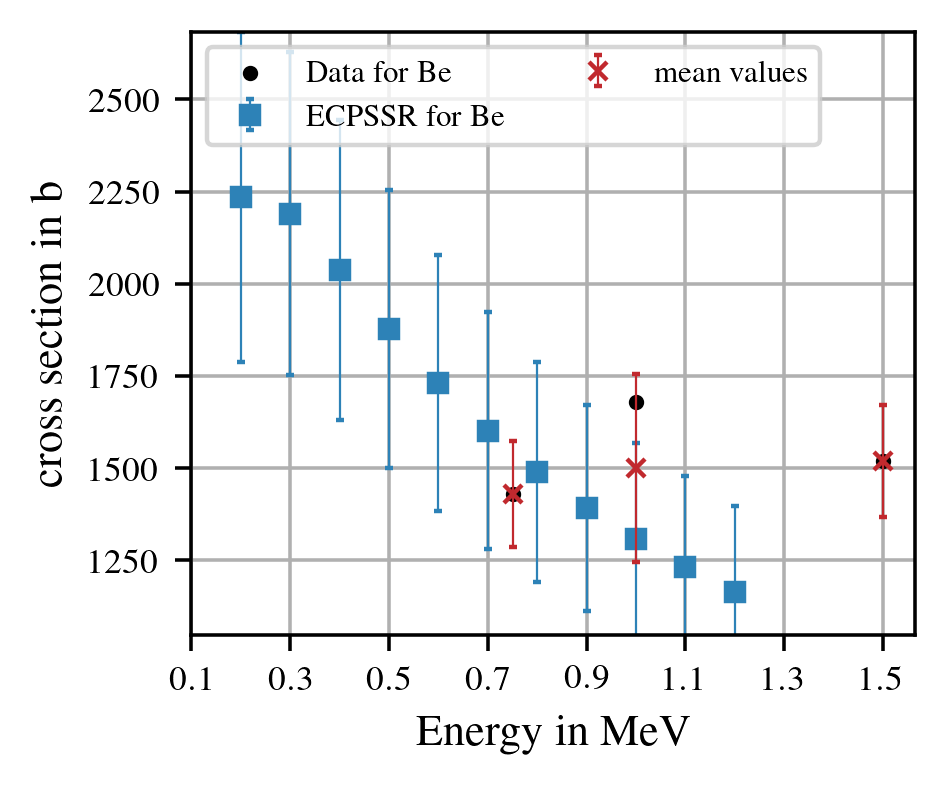

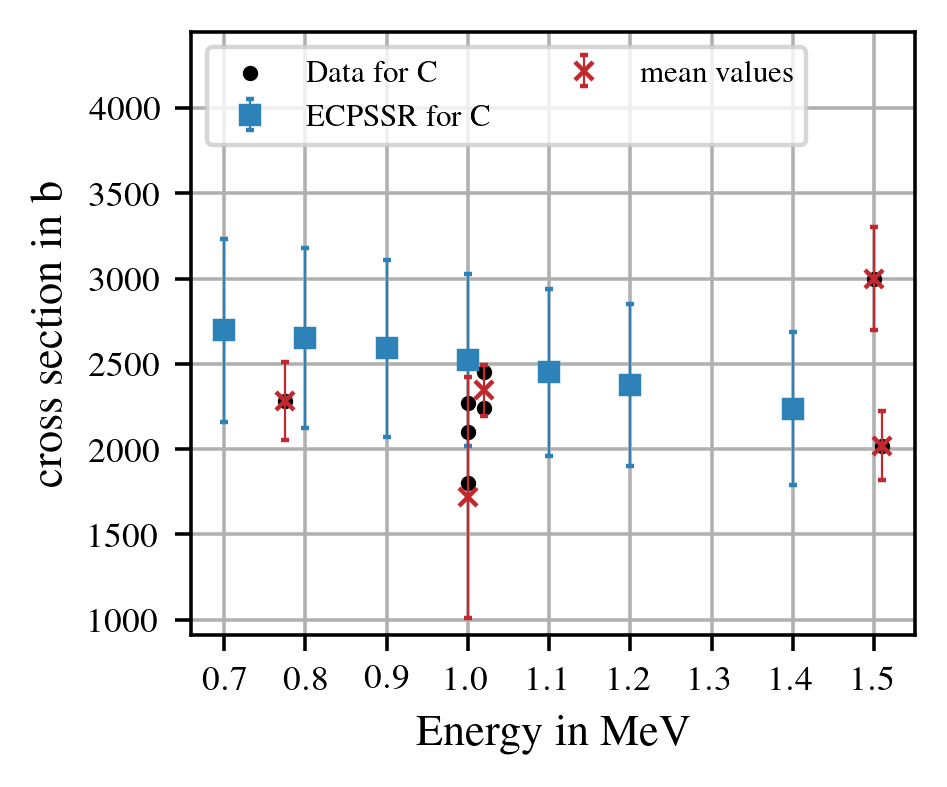

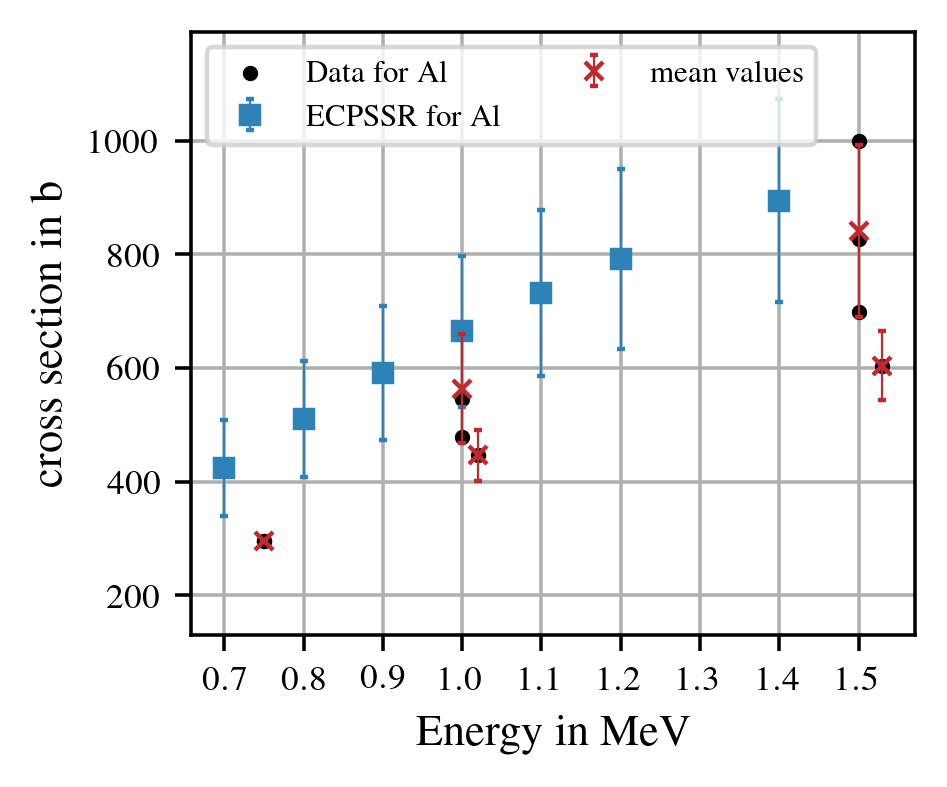

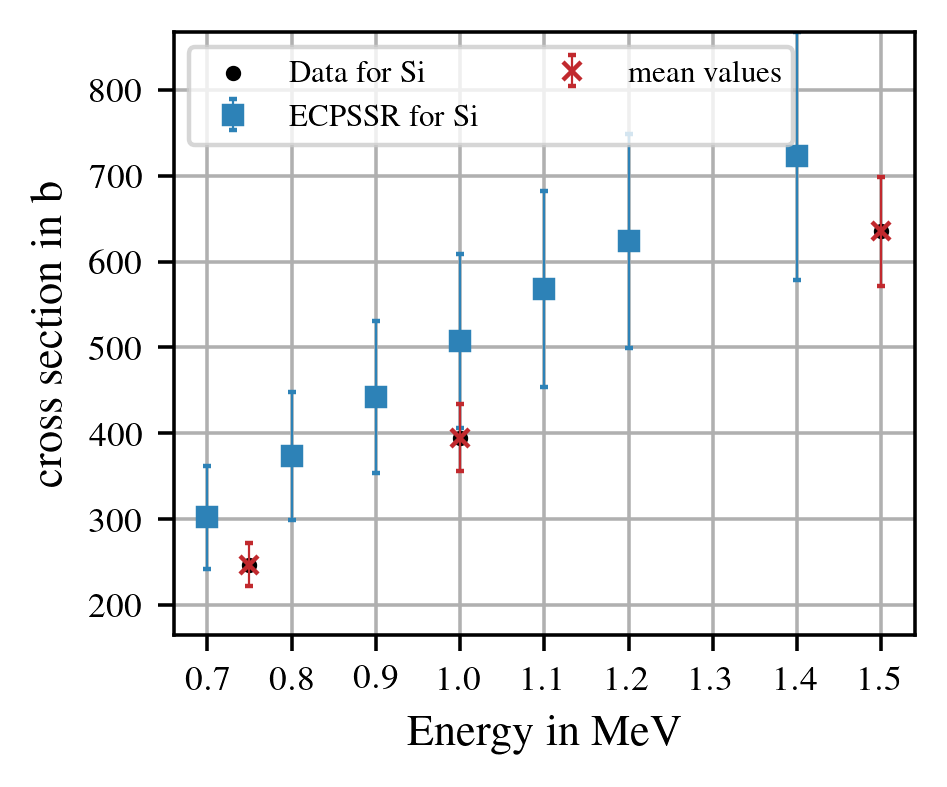

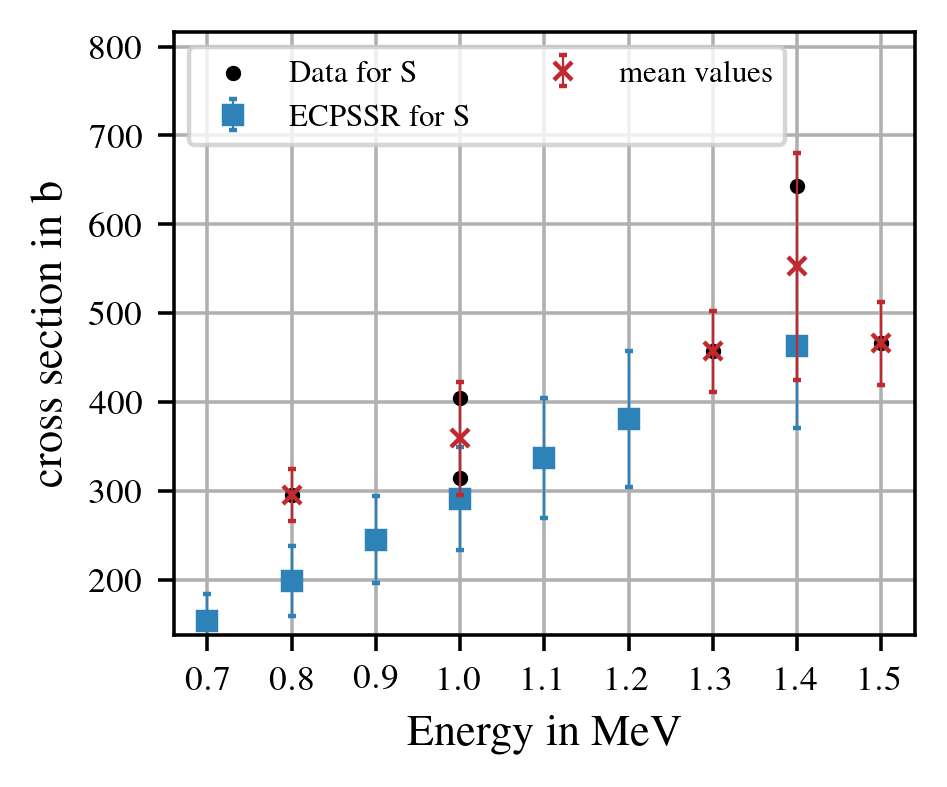

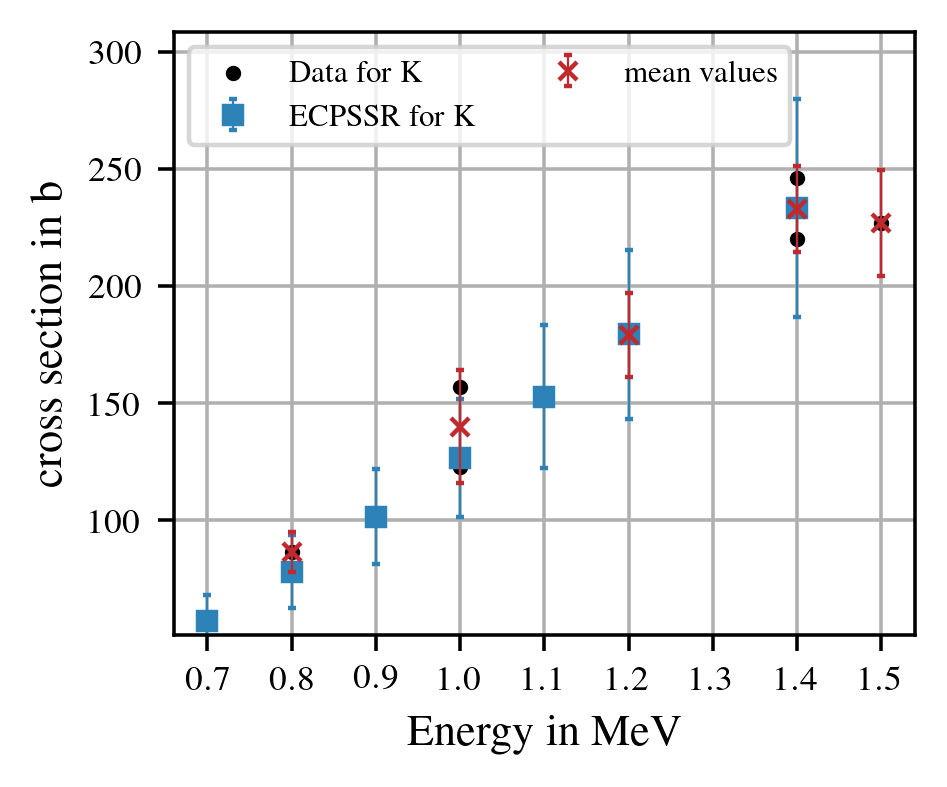

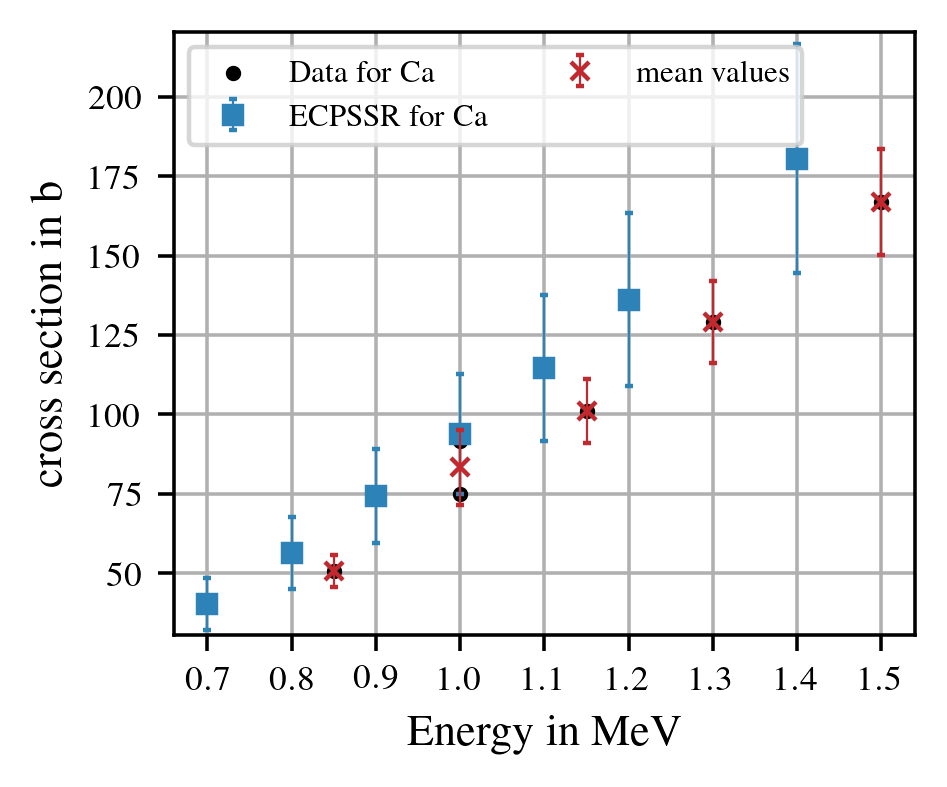

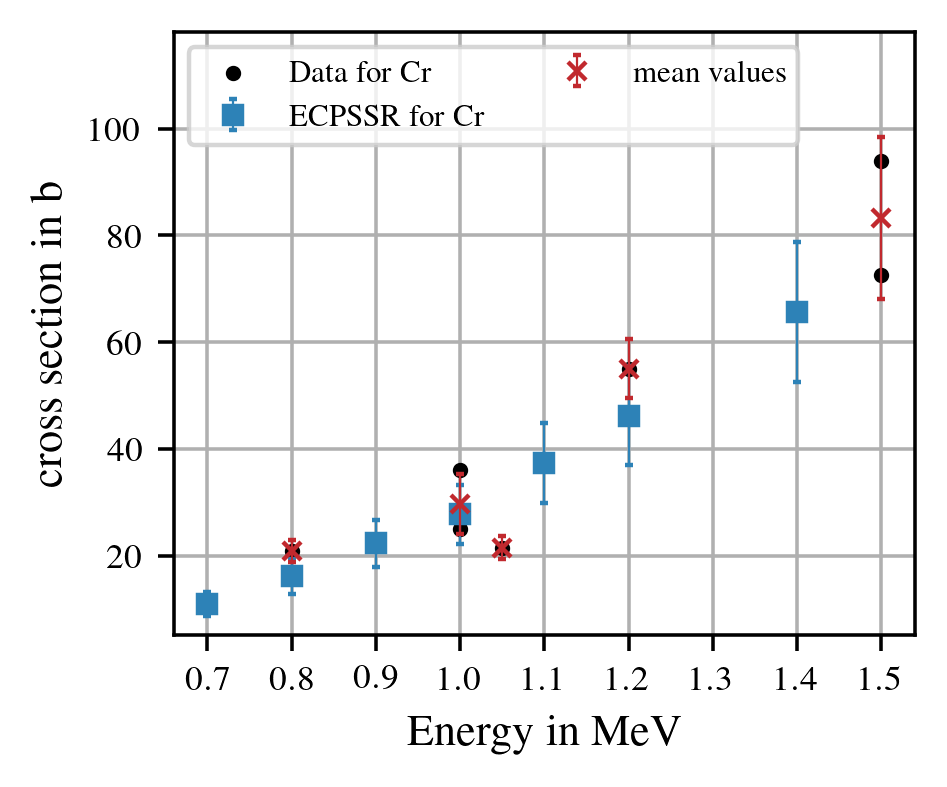

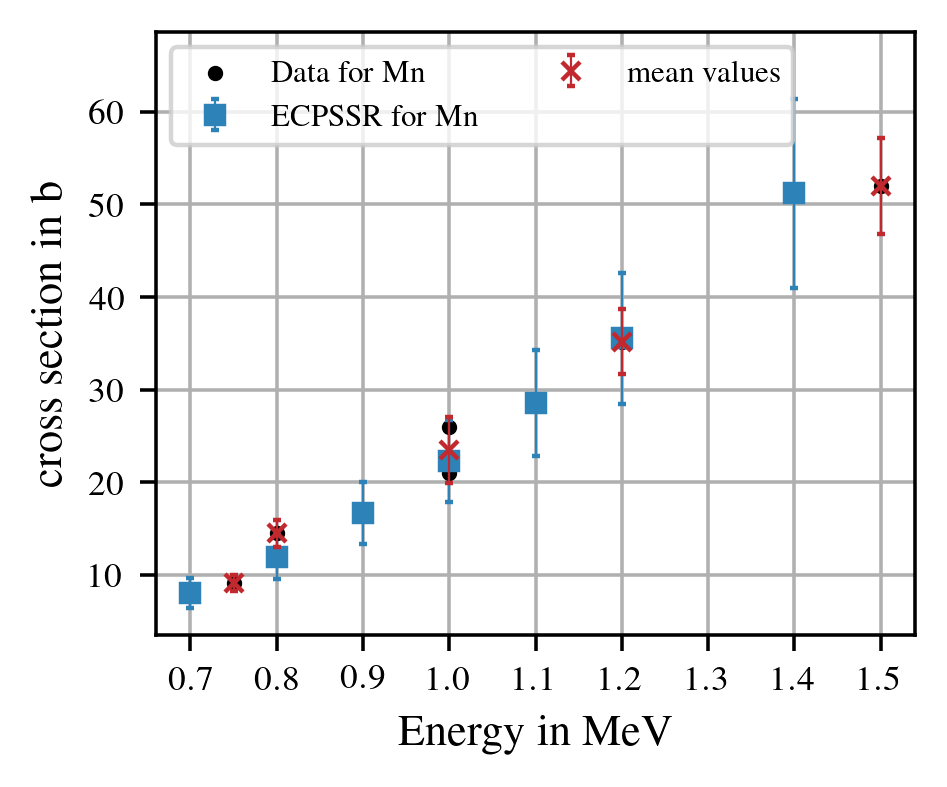

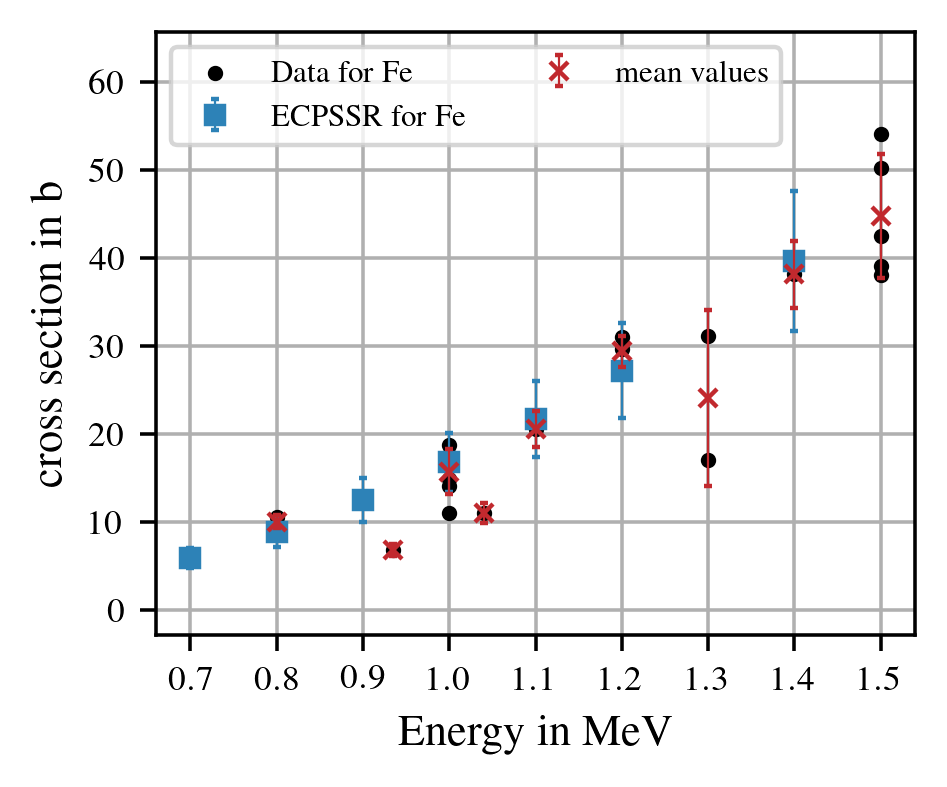

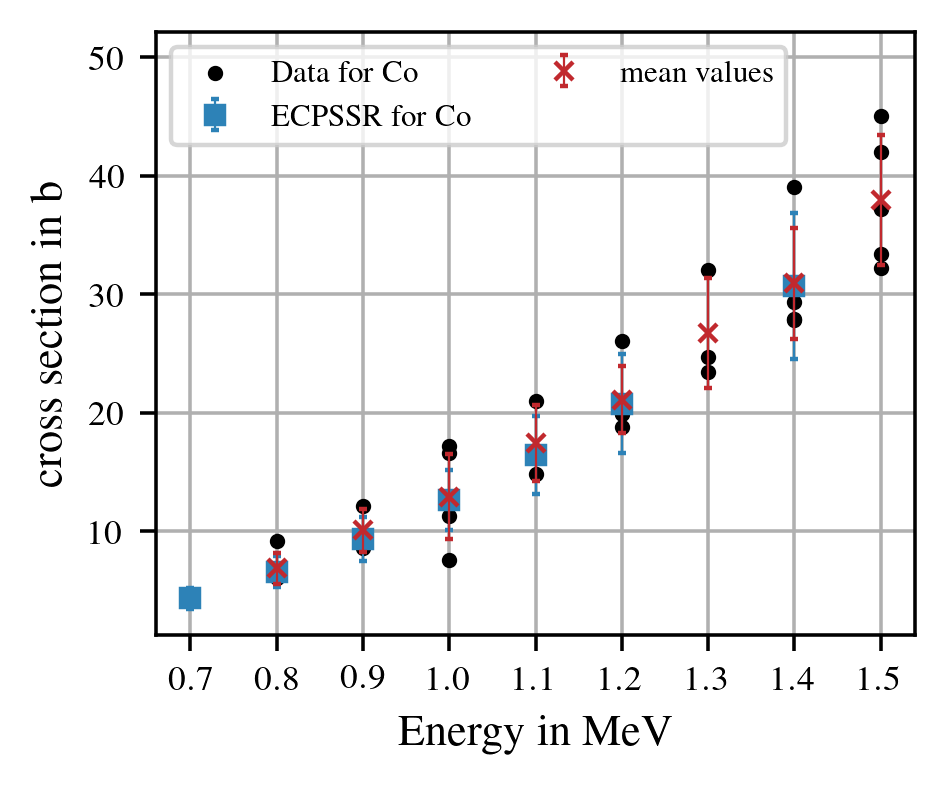

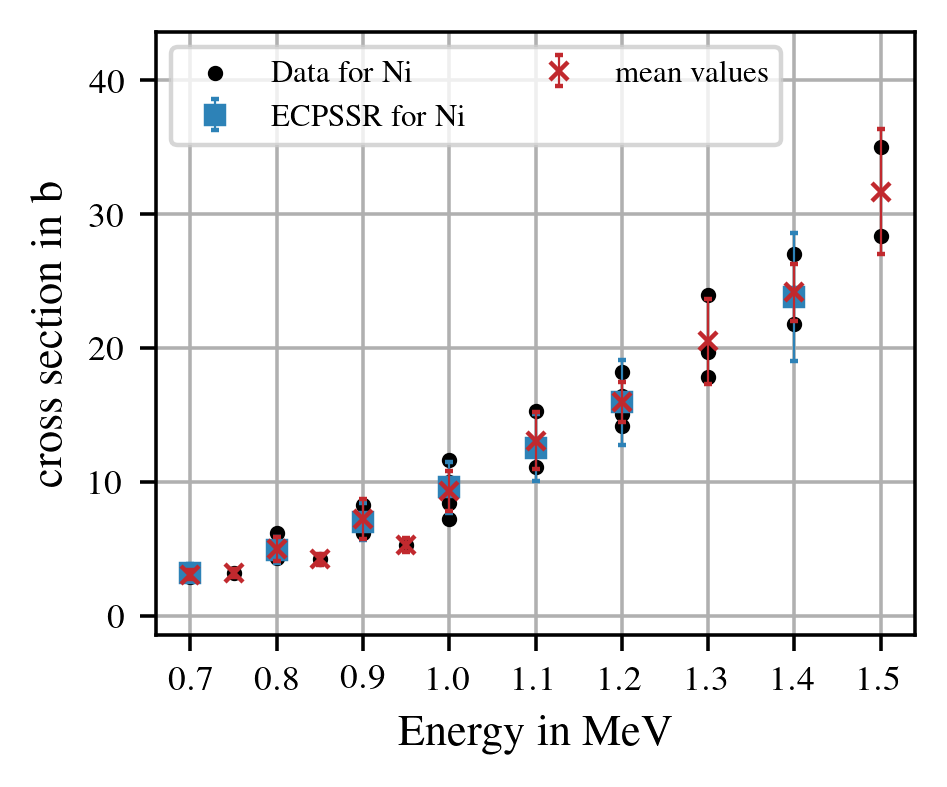

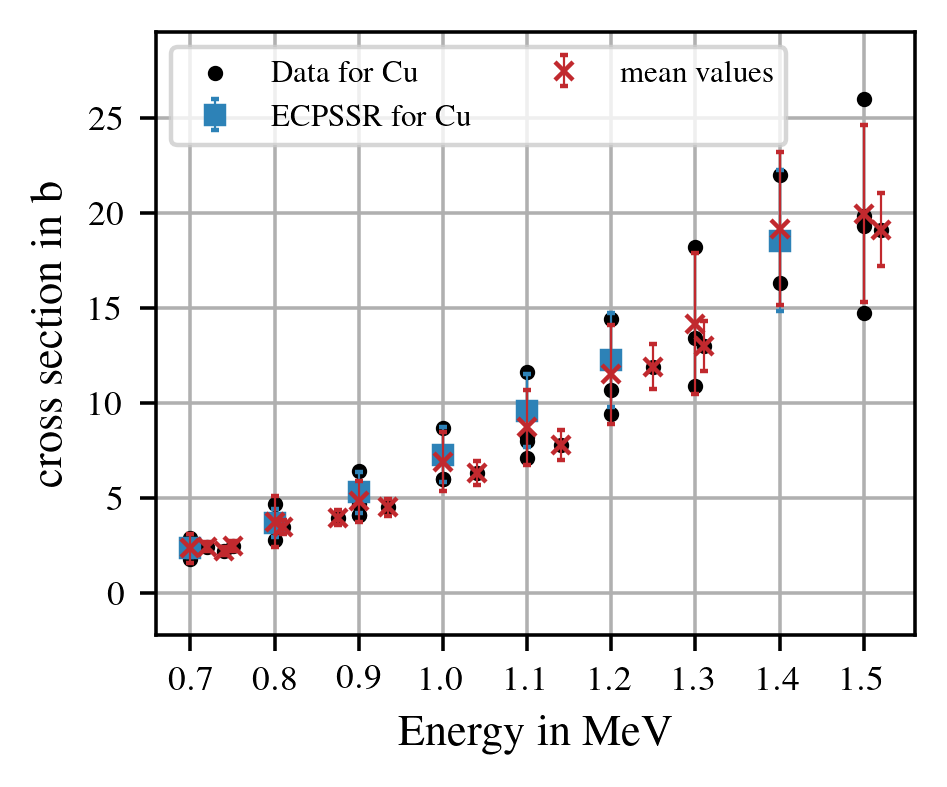

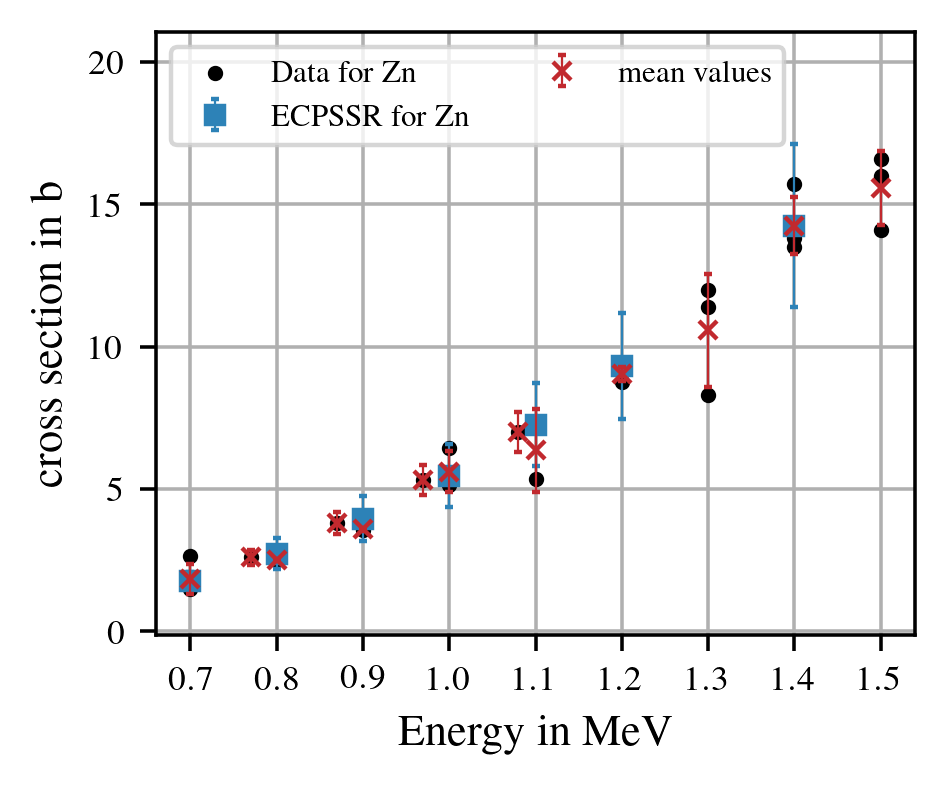

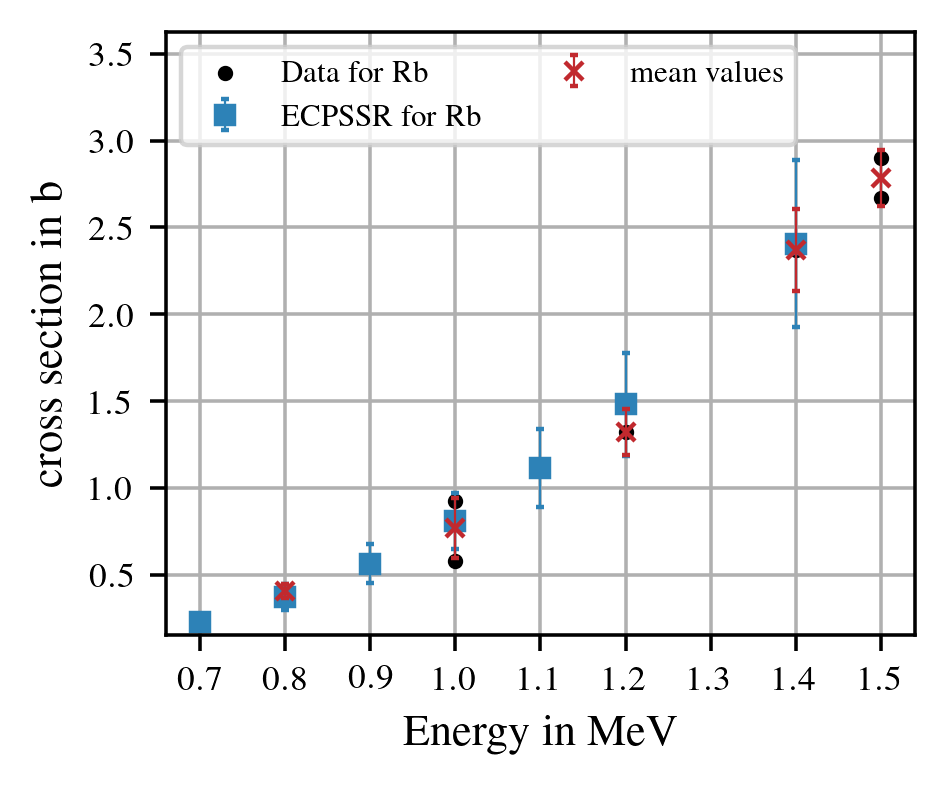

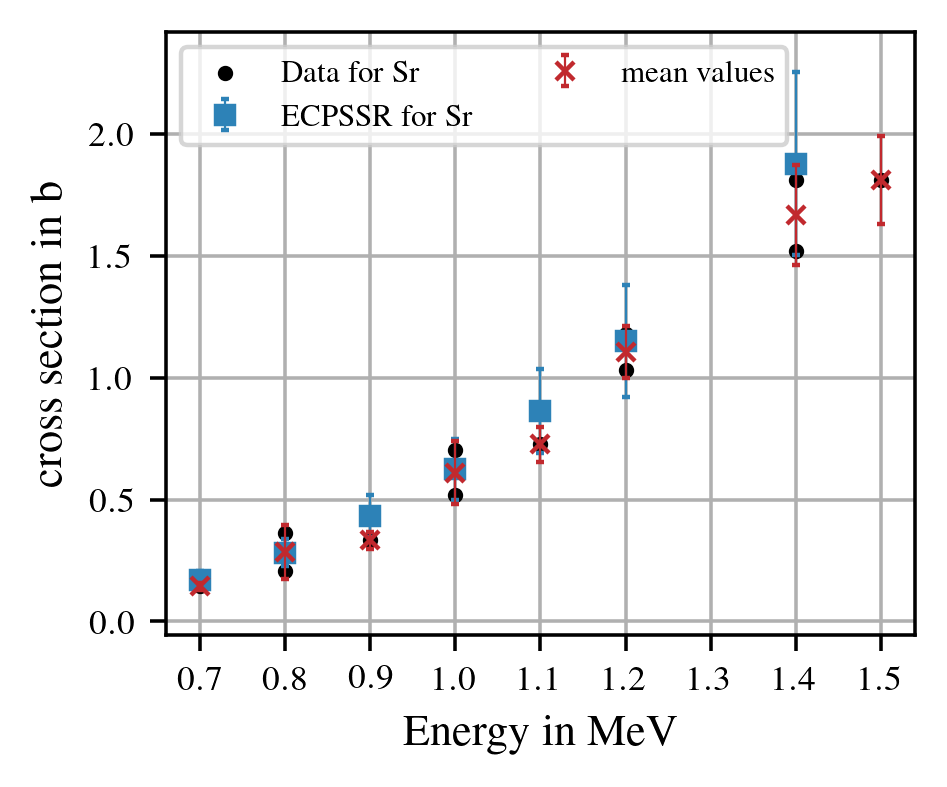

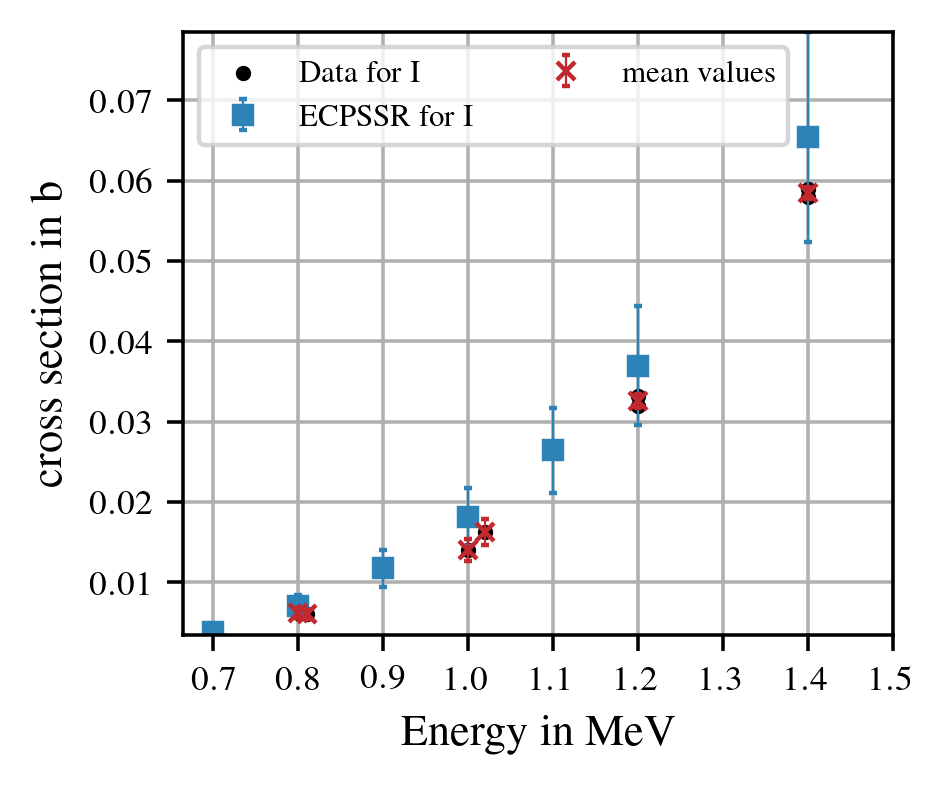

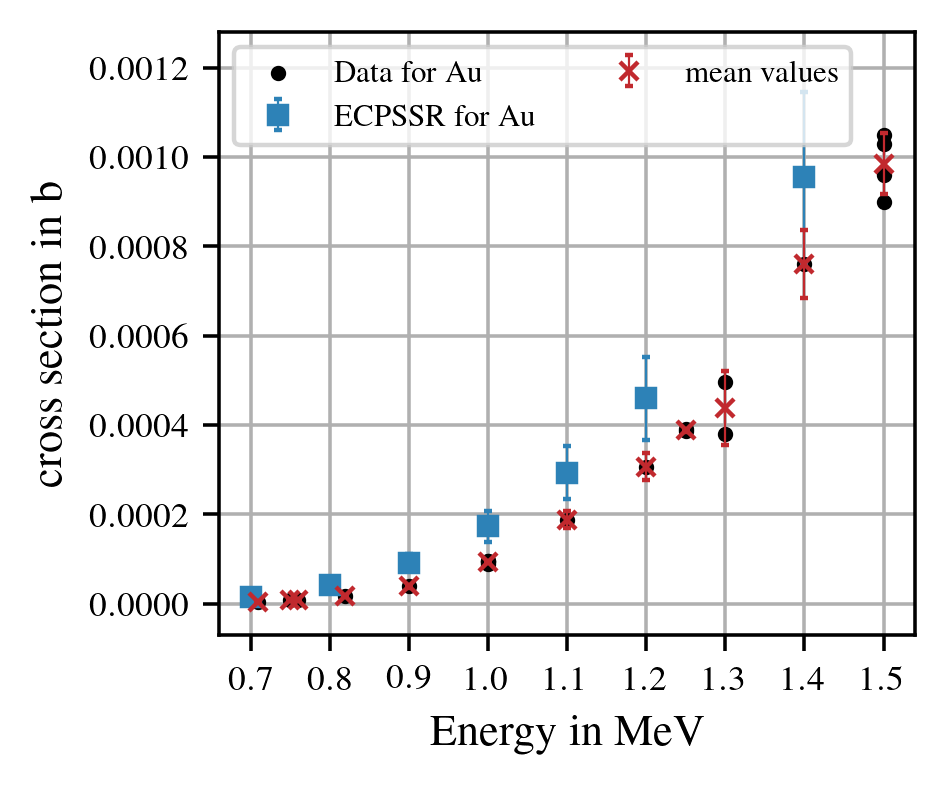

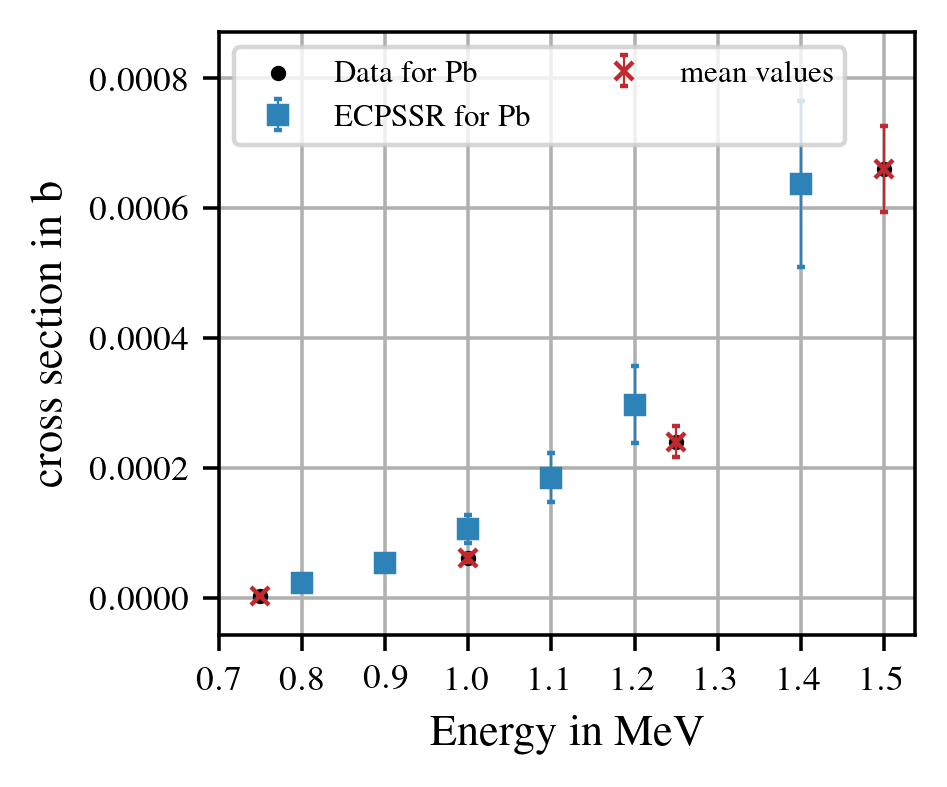

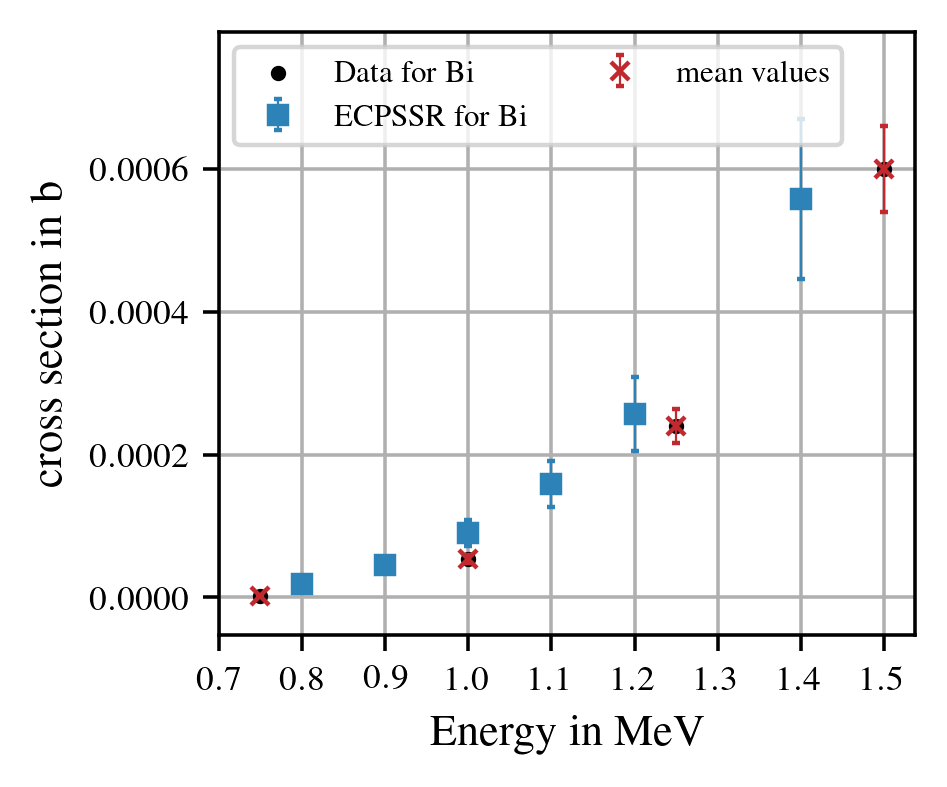

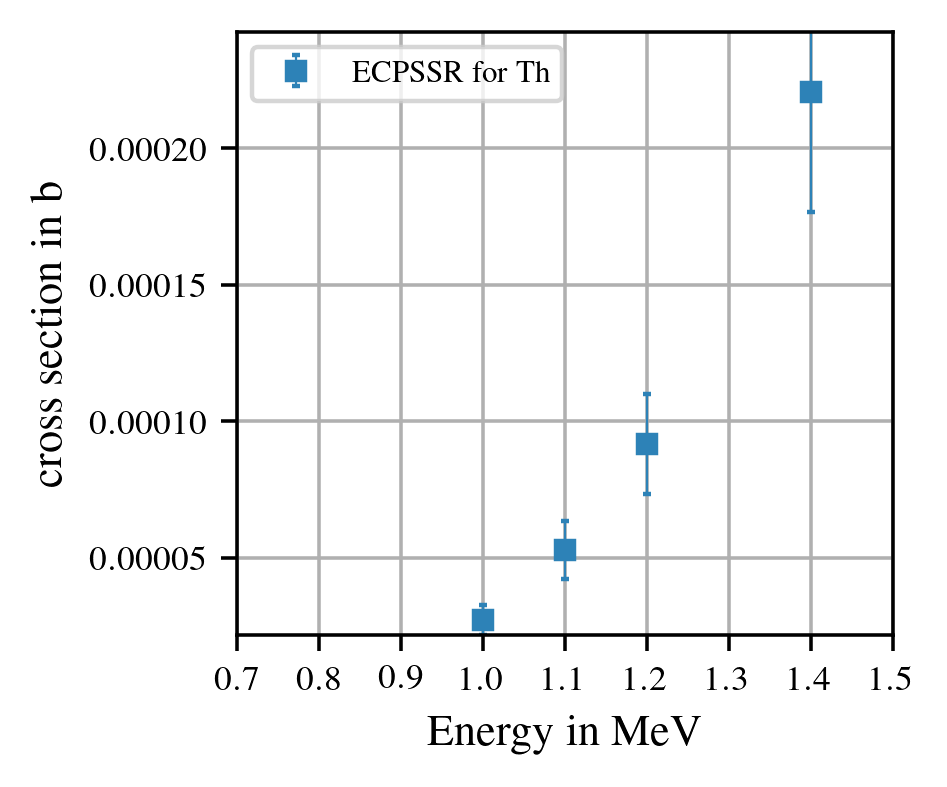

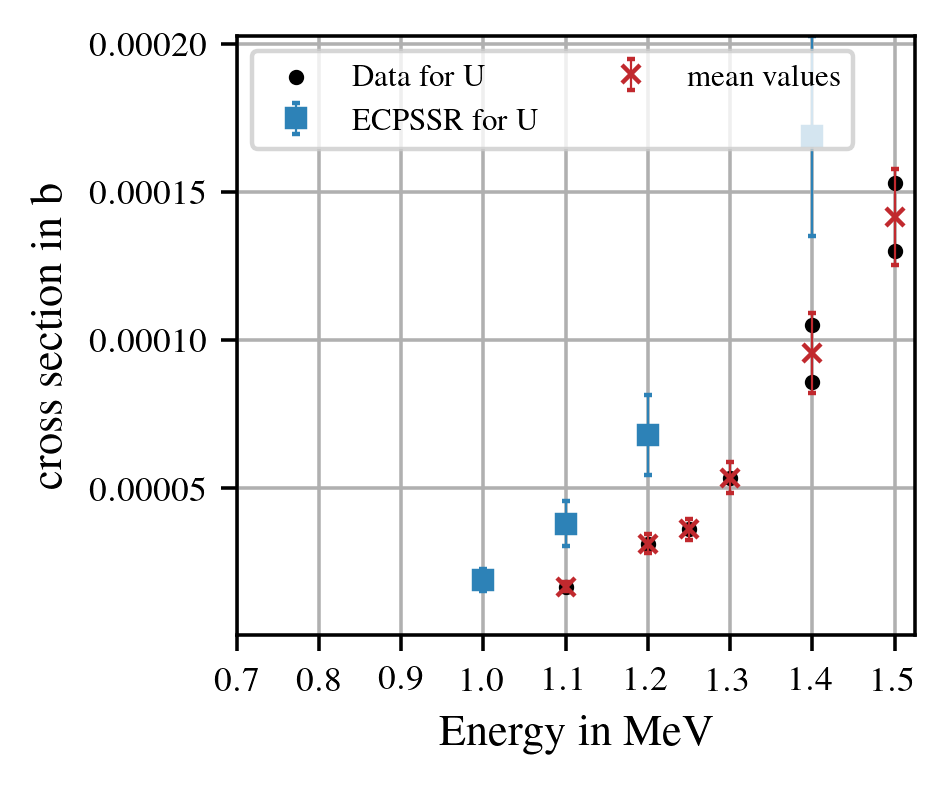

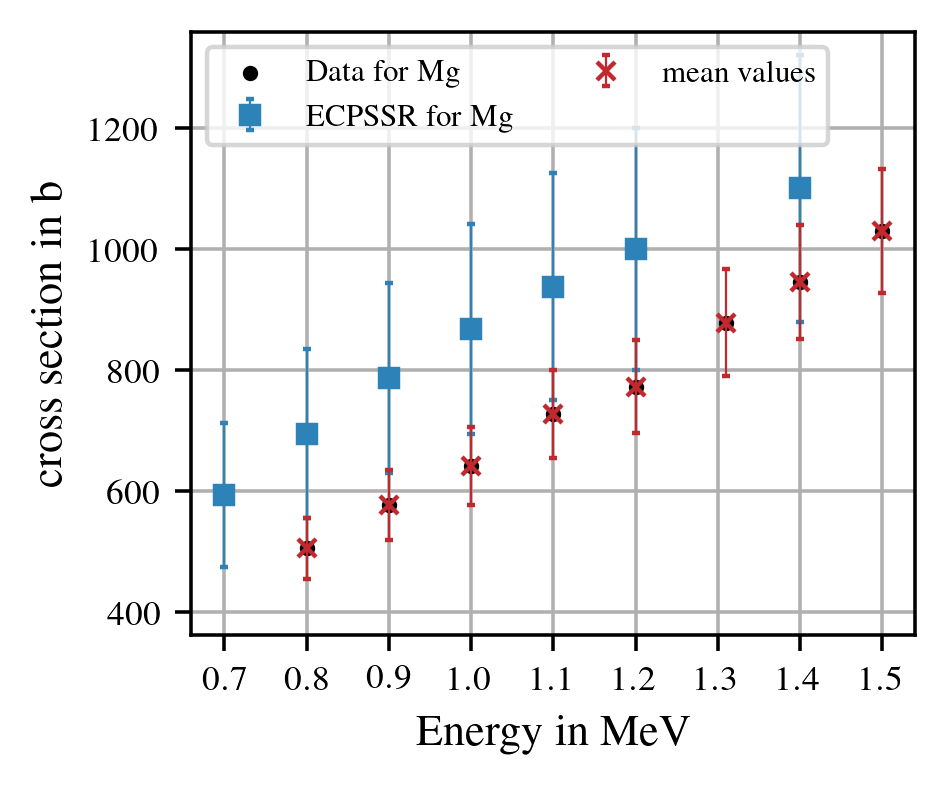

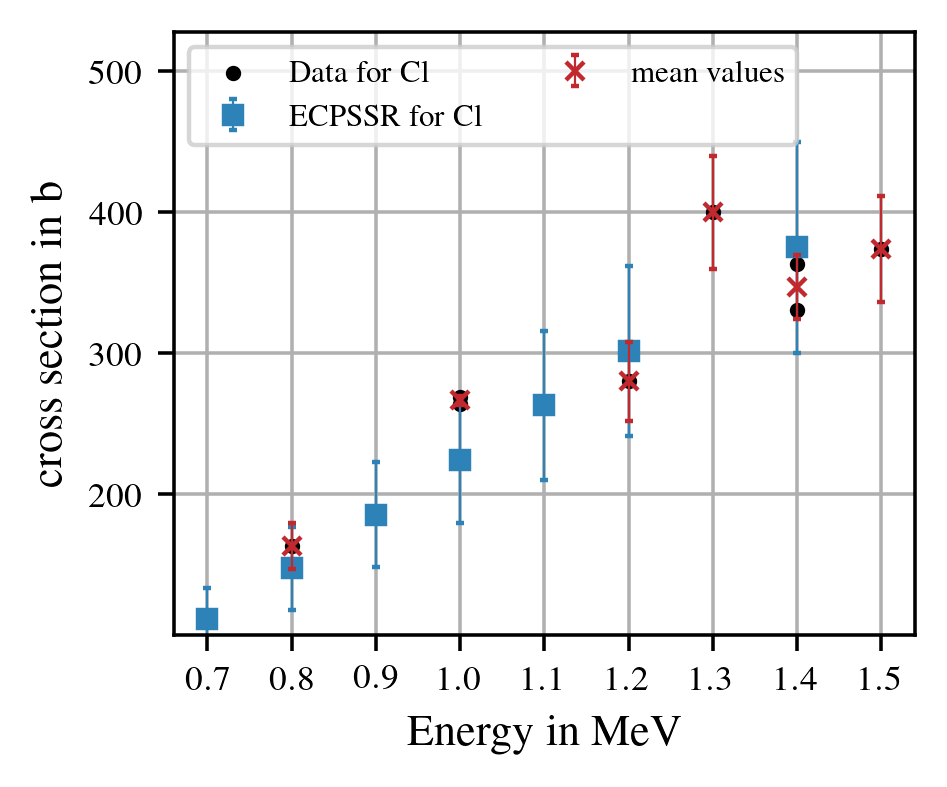

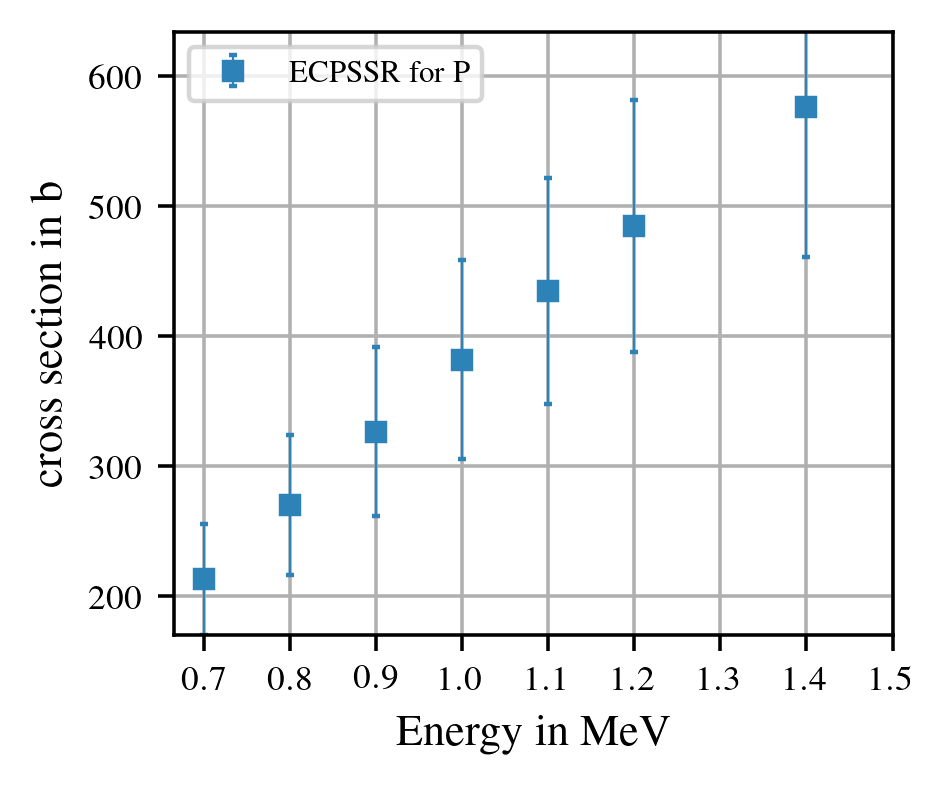

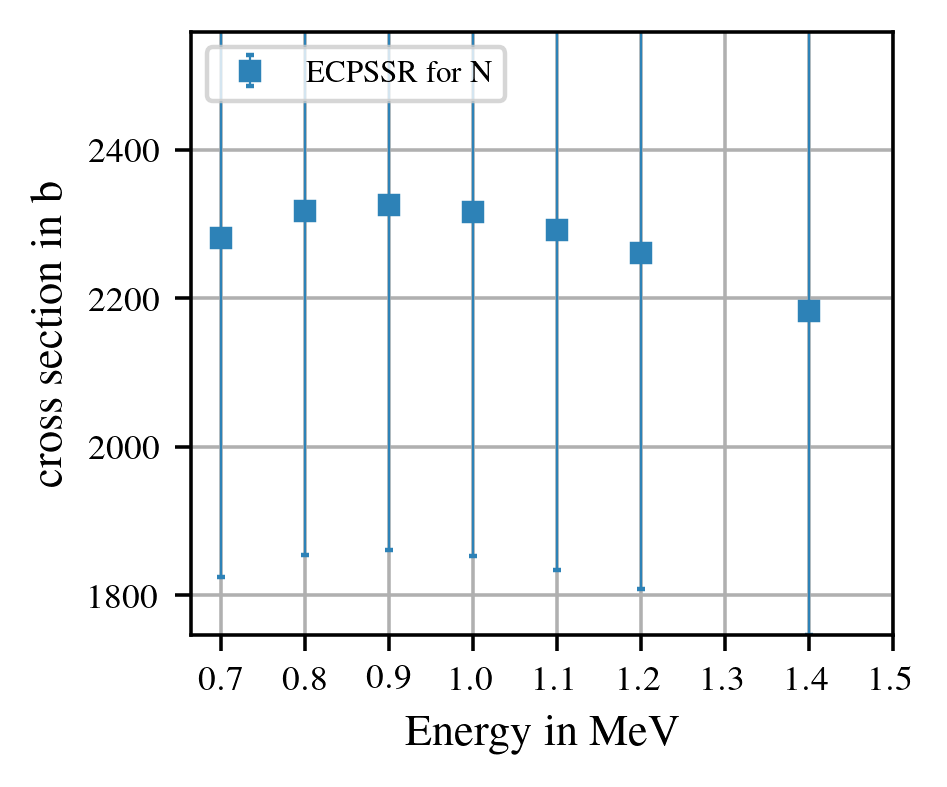

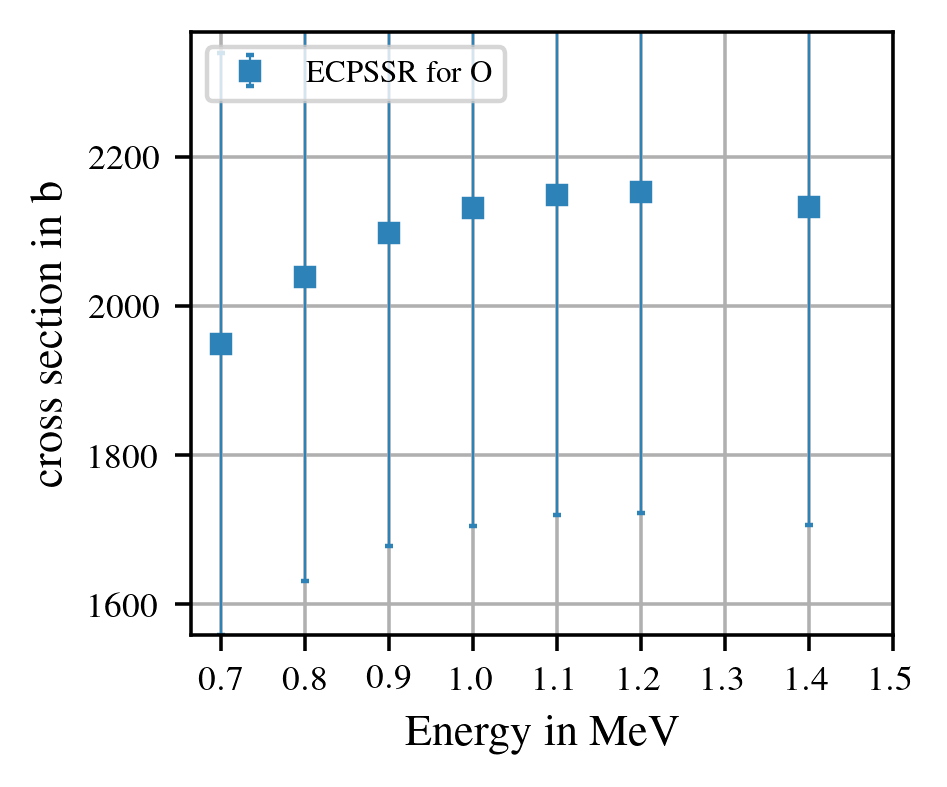

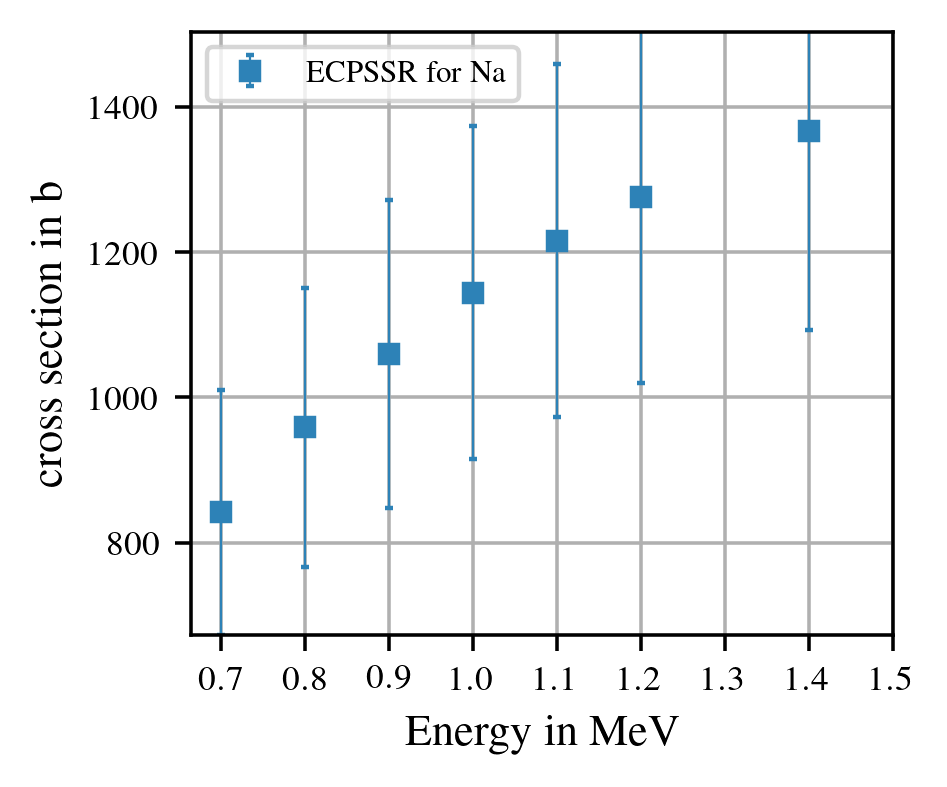

['Be', 'C', 'Al', 'Si', 'S', 'K', 'Ca', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Rb', 'Sr', 'I', 'Au', 'Pb', 'Bi', 'Th', 'U', 'Mg', 'Cl', 'P', 'N', 'O', 'Na']


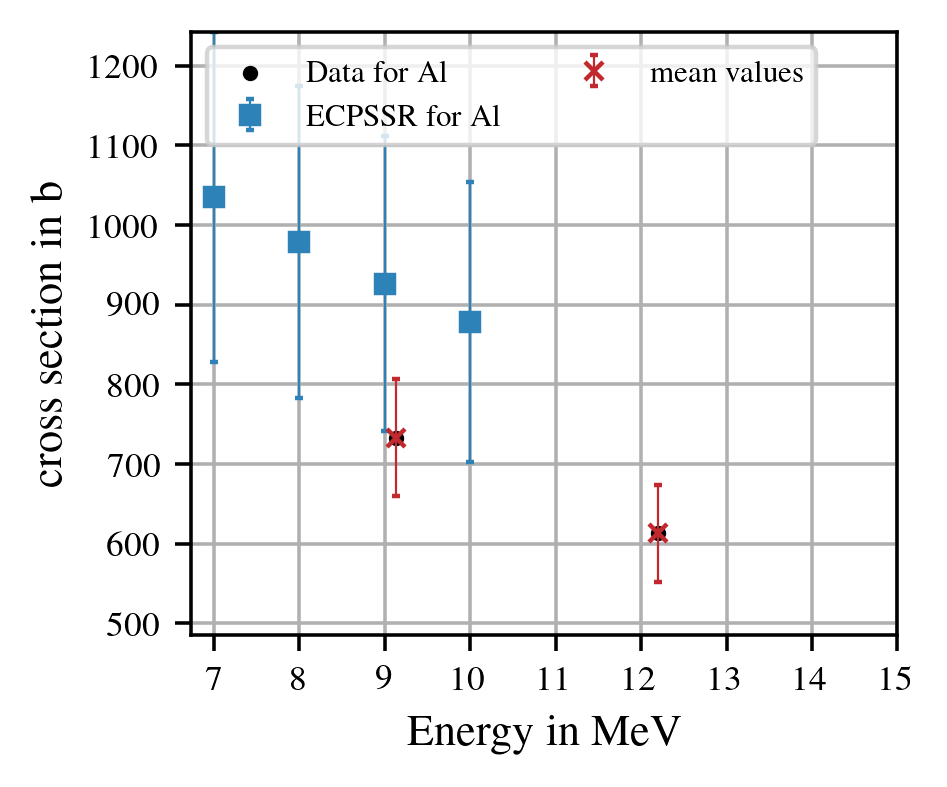

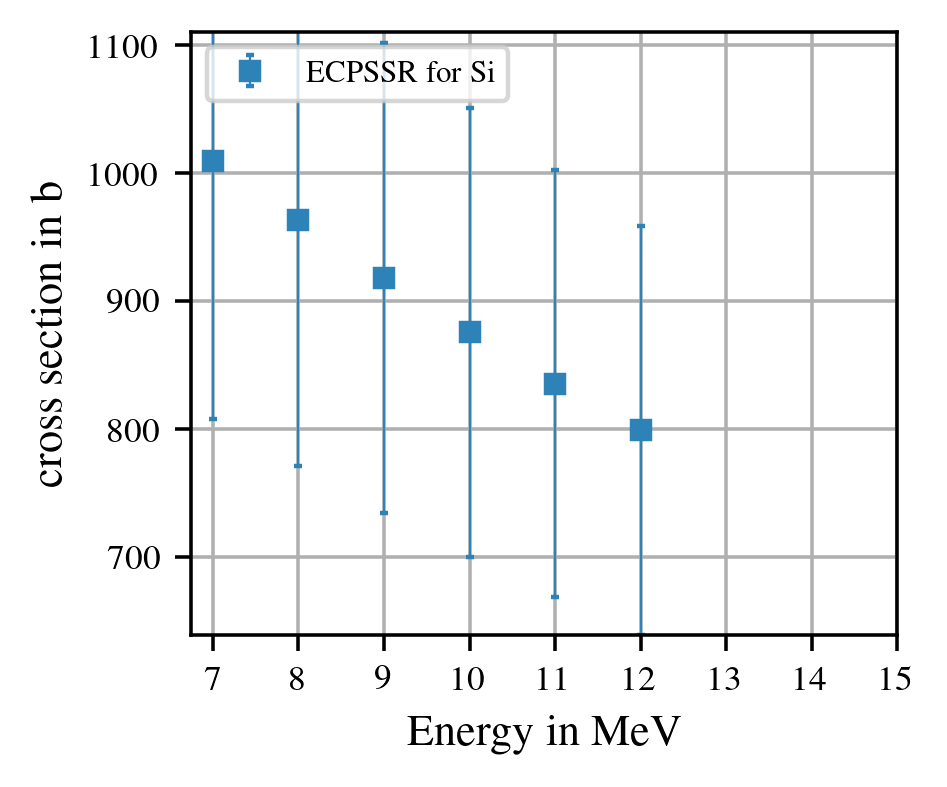

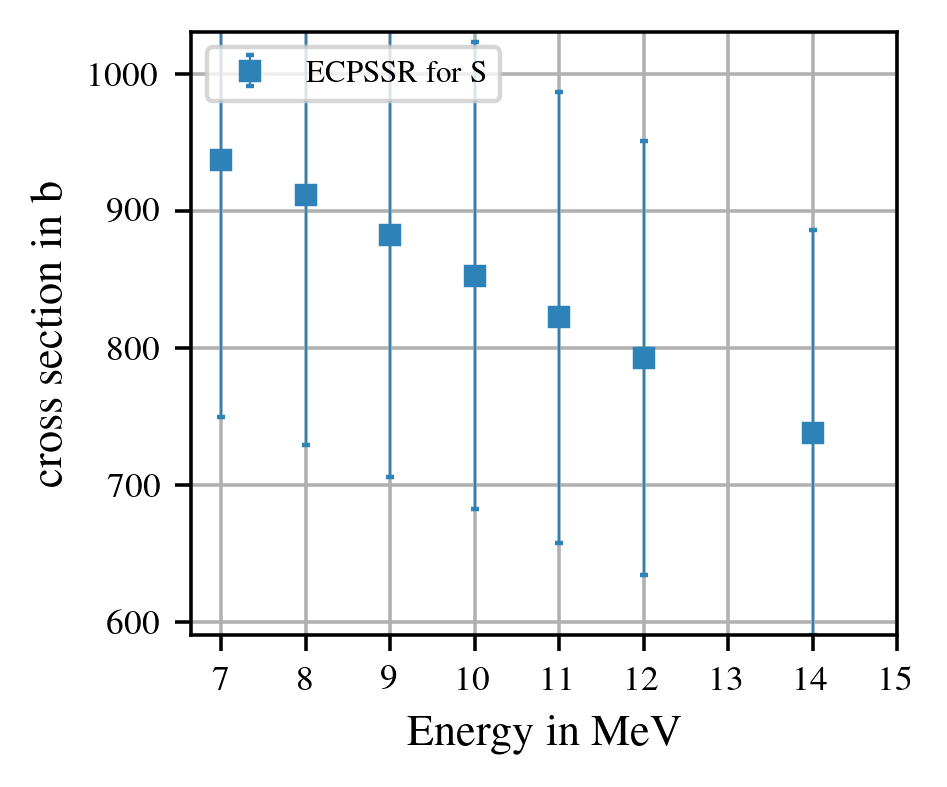

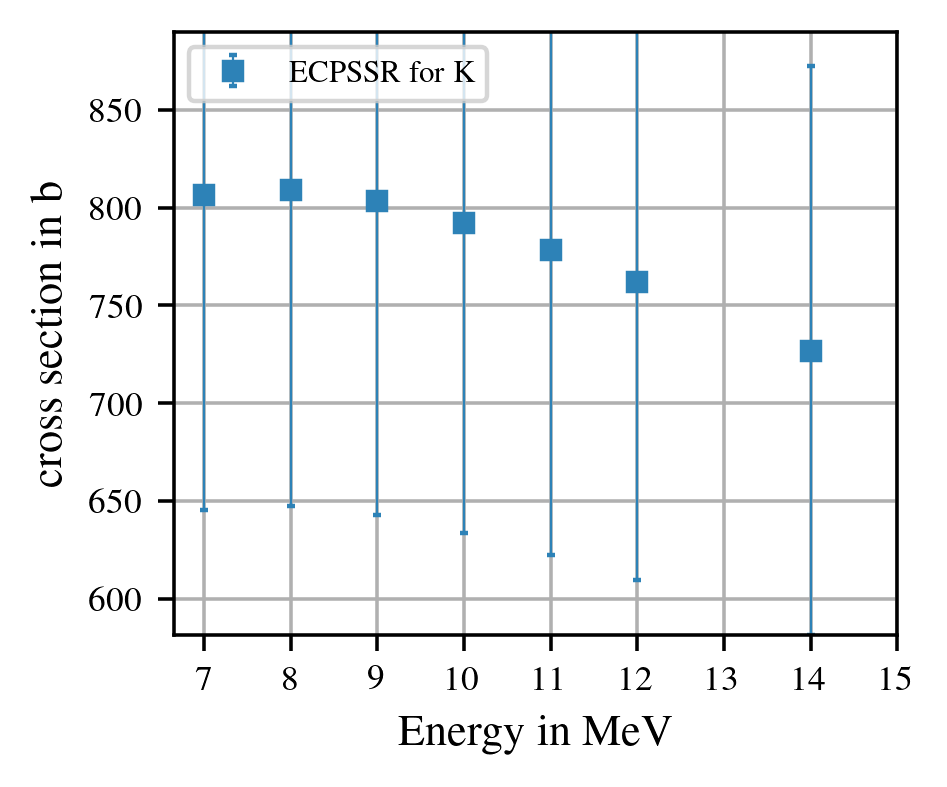

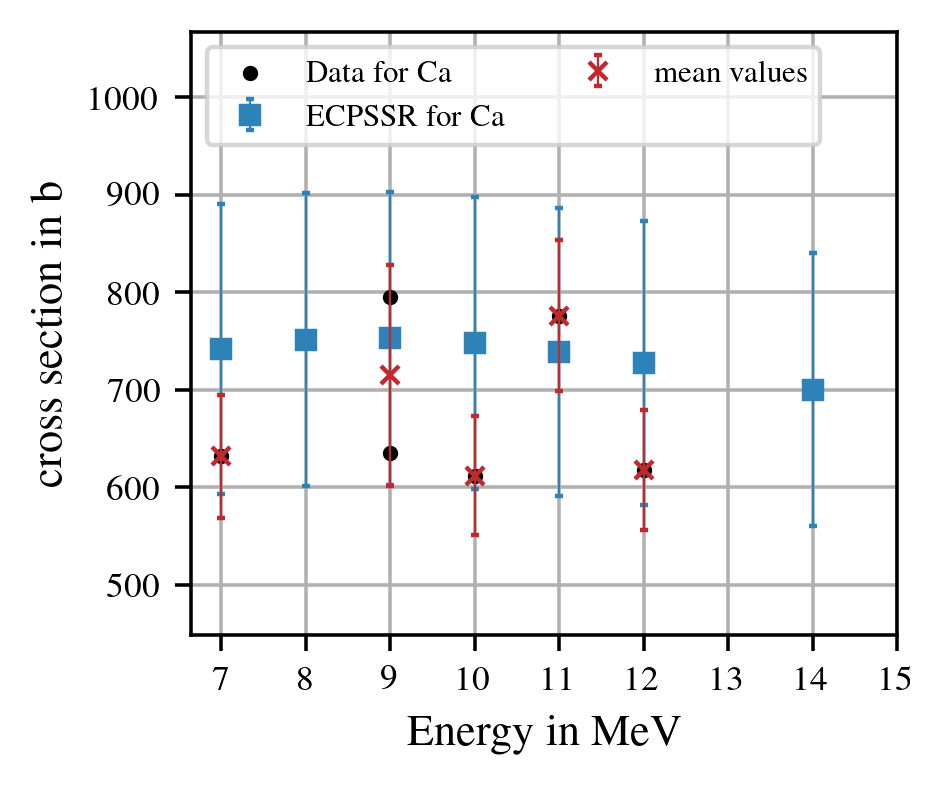

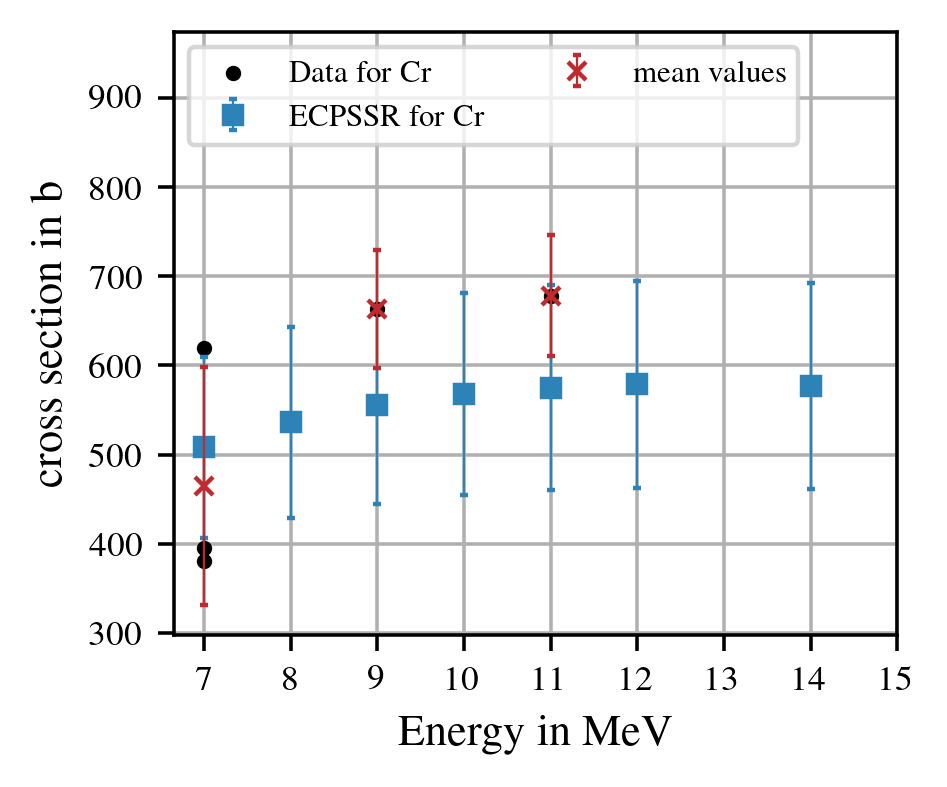

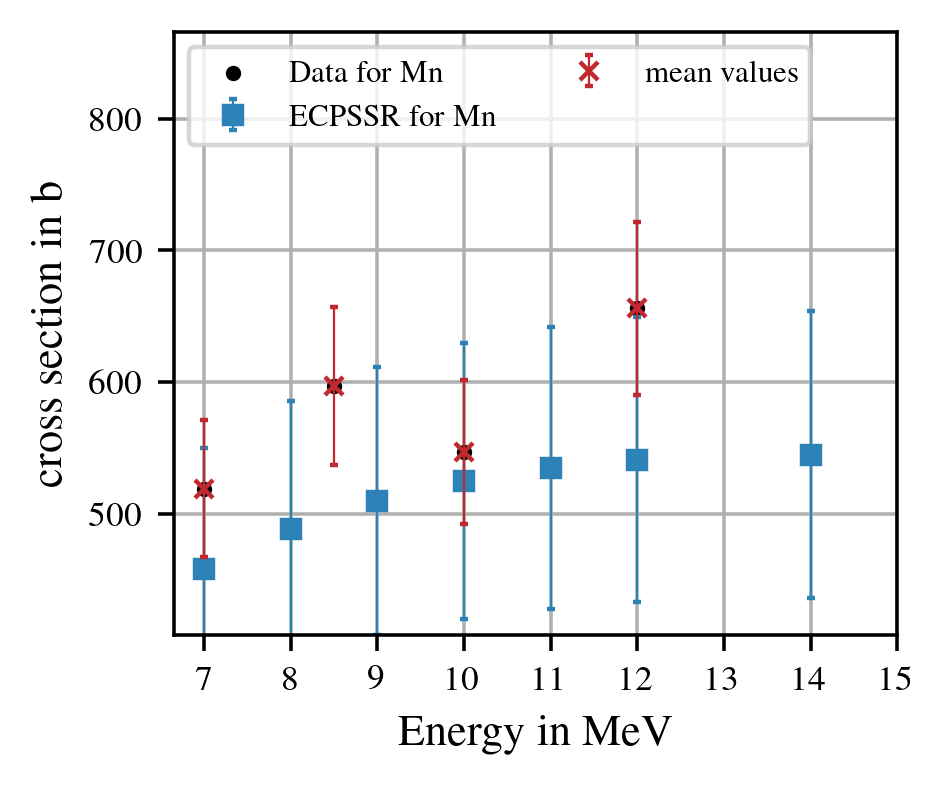

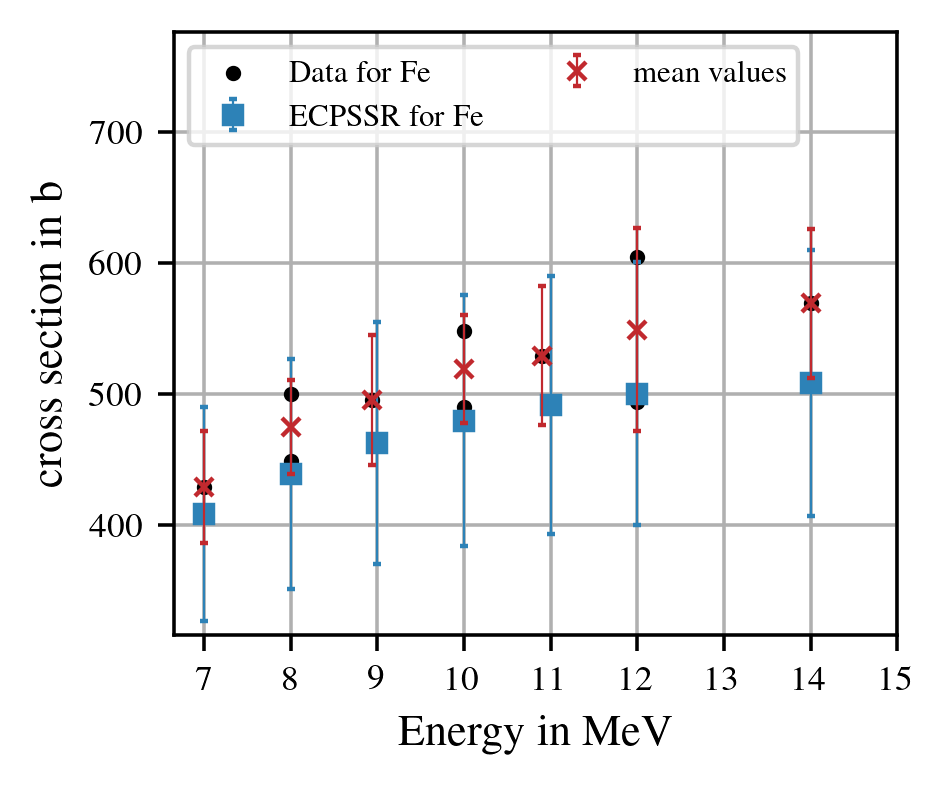

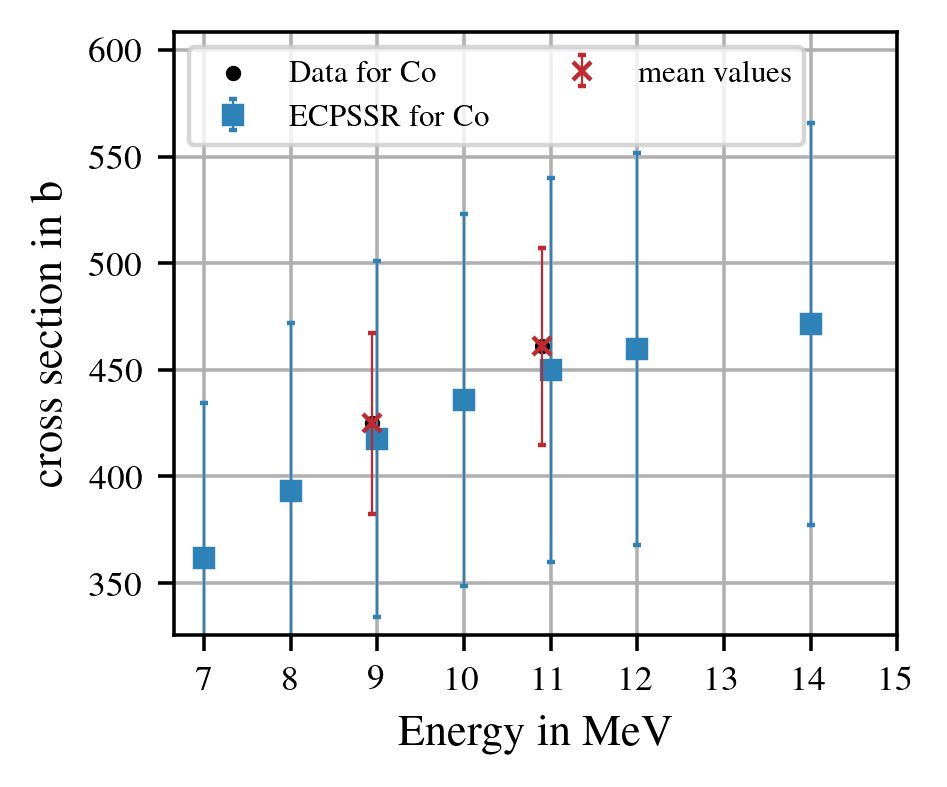

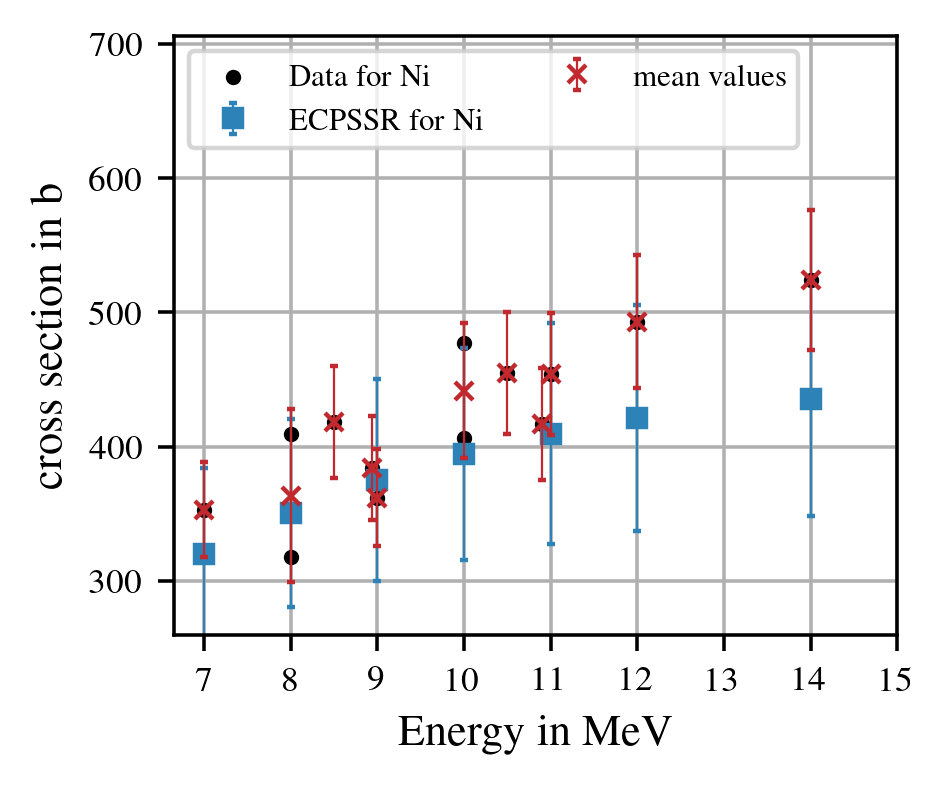

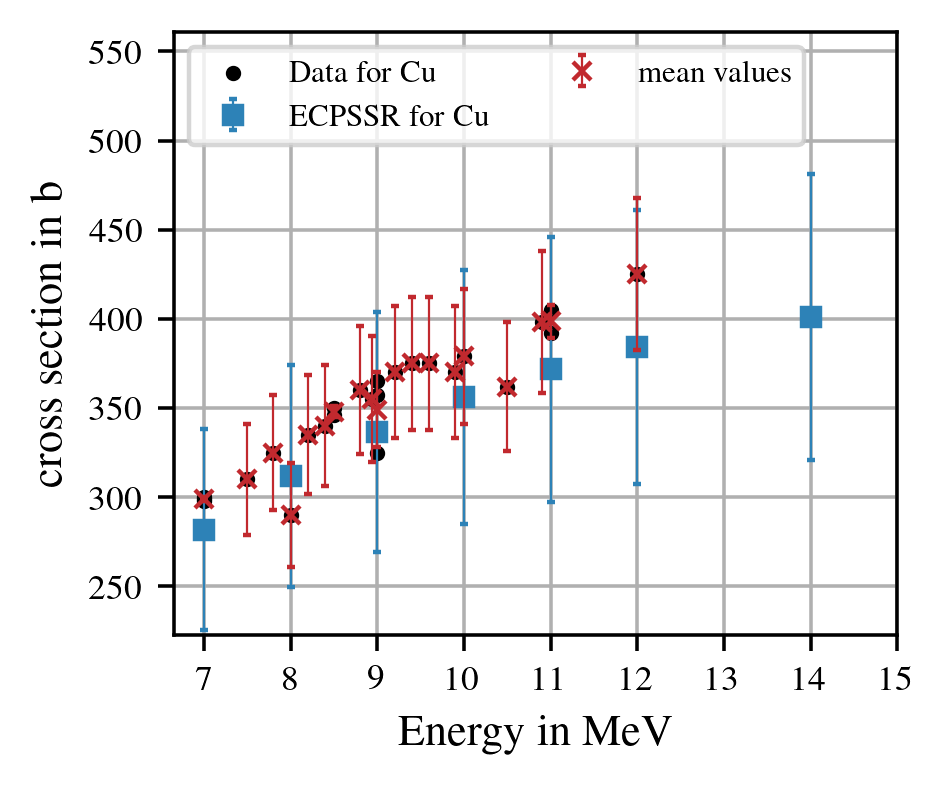

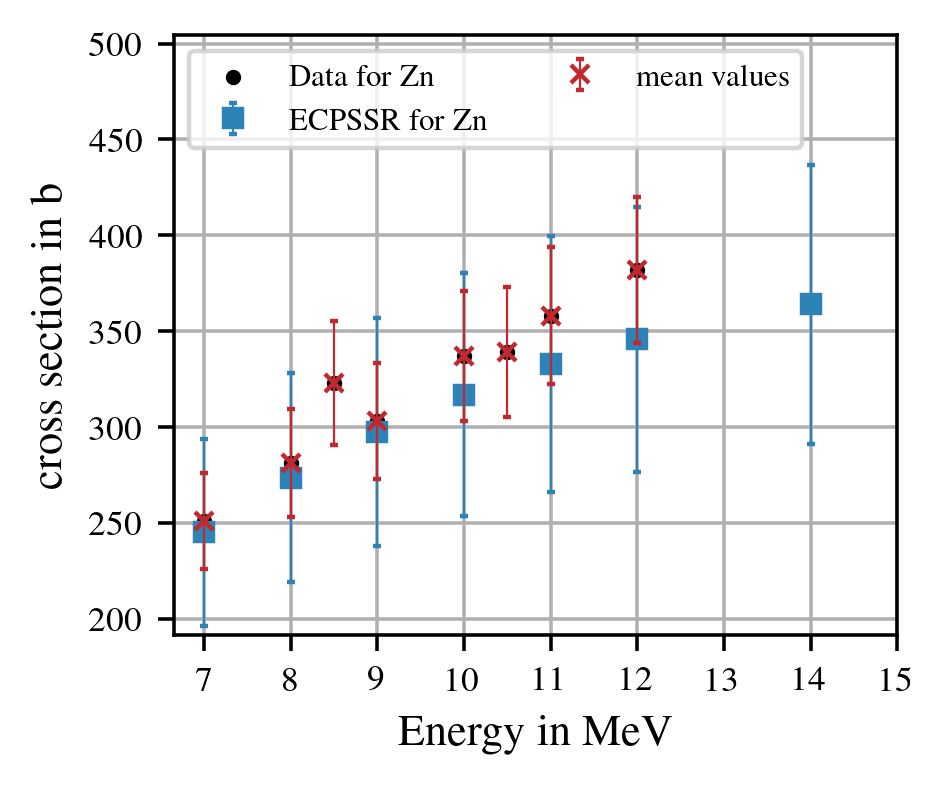

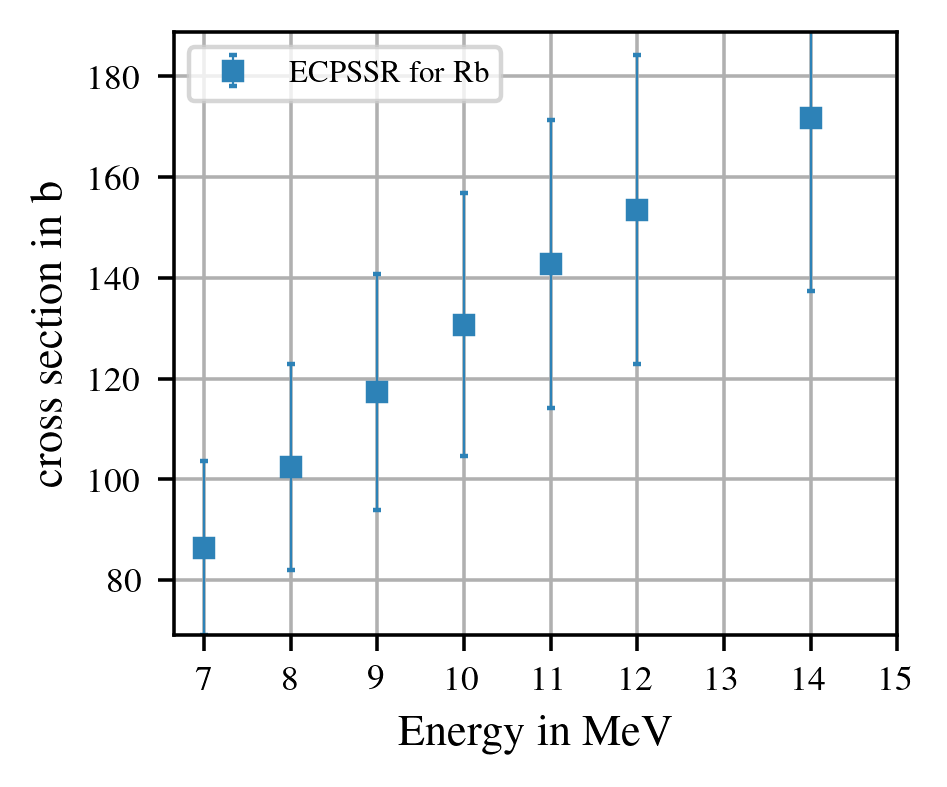

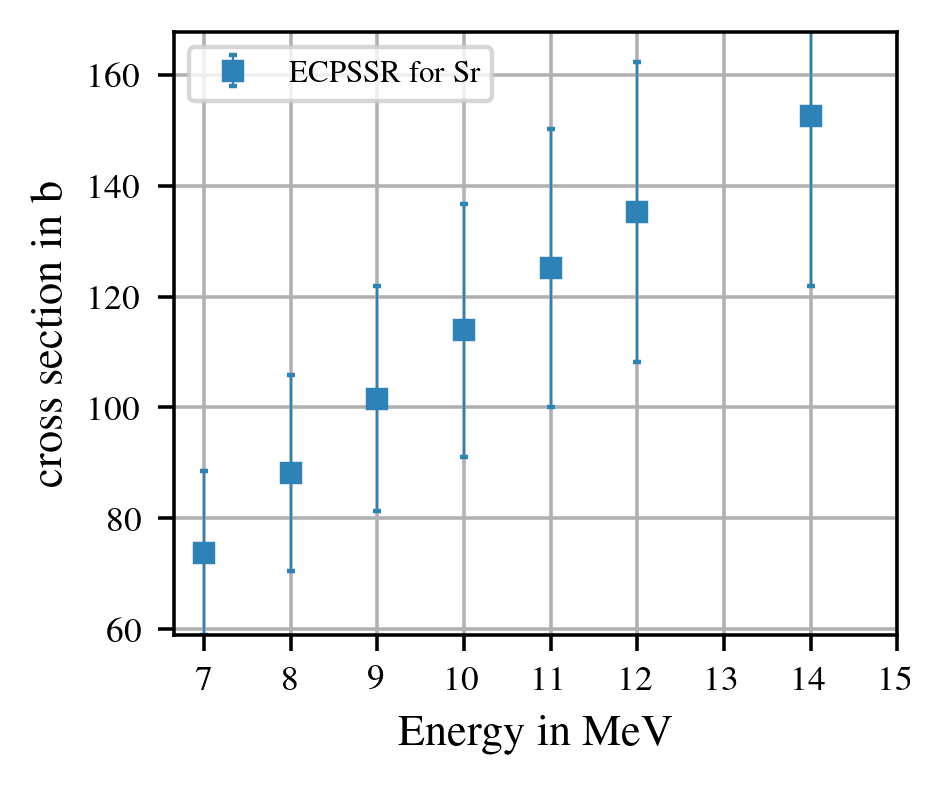

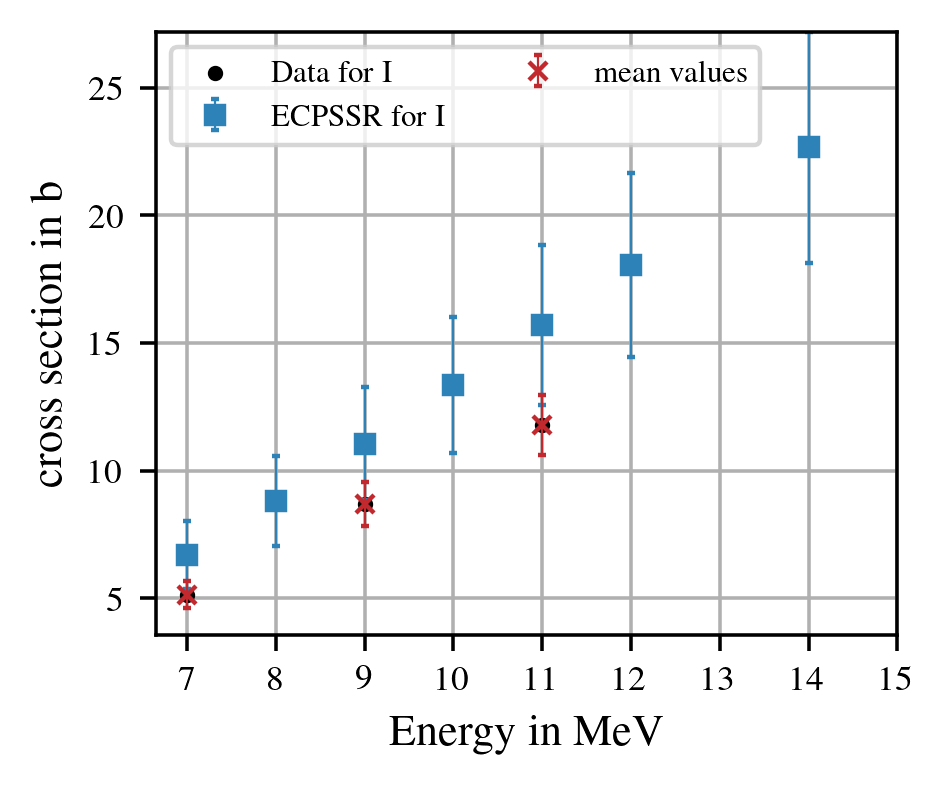

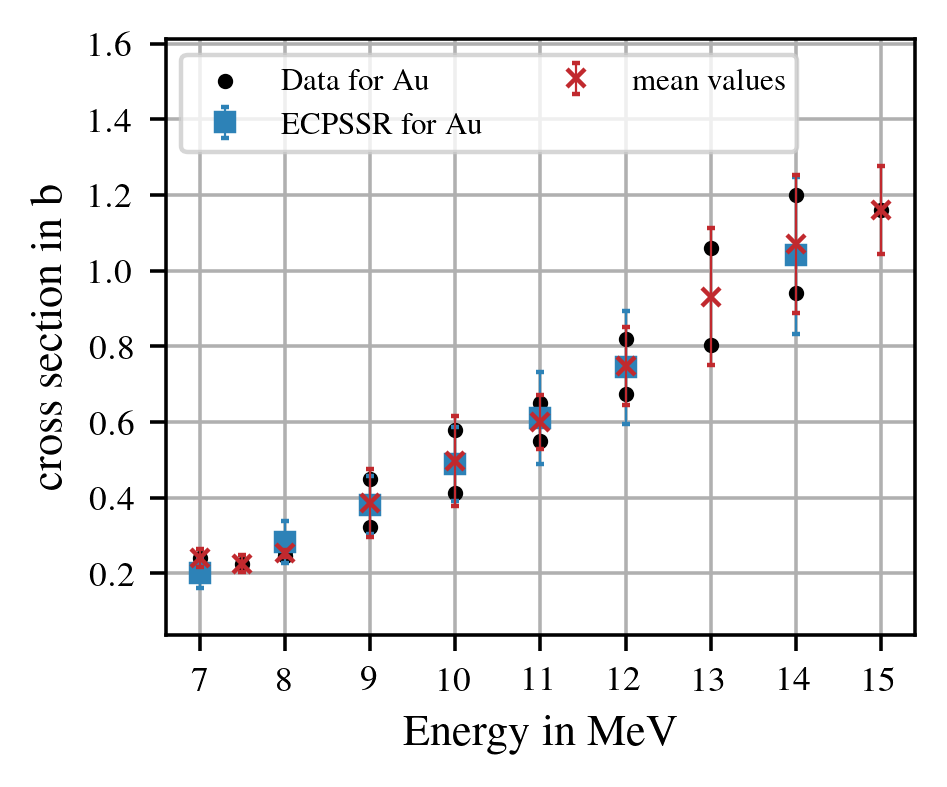

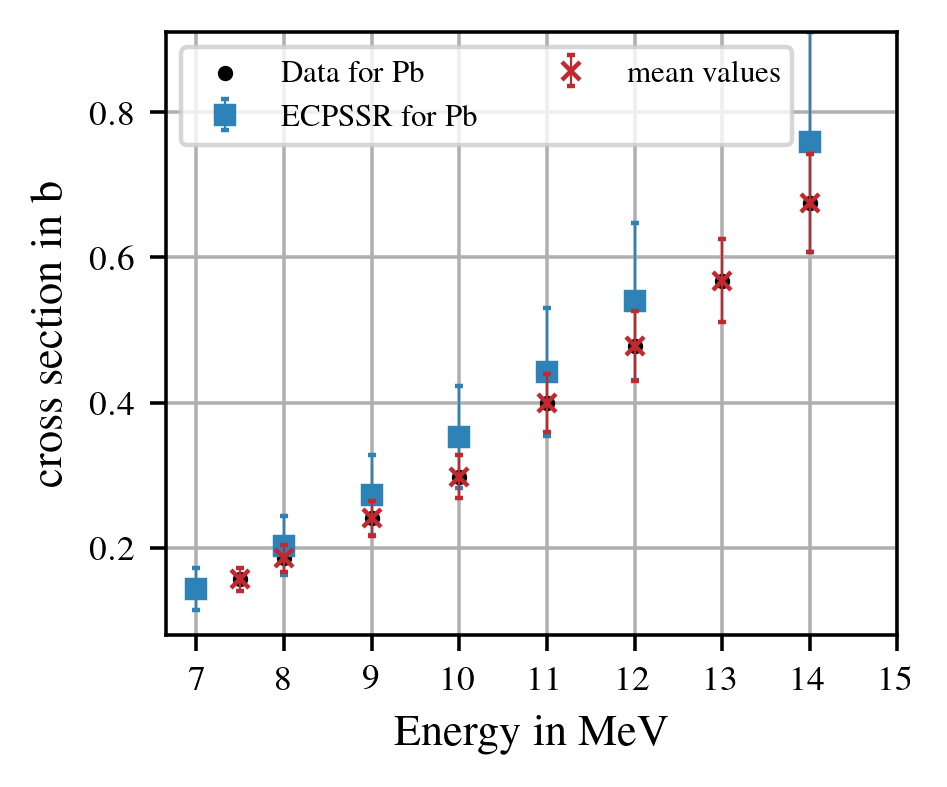

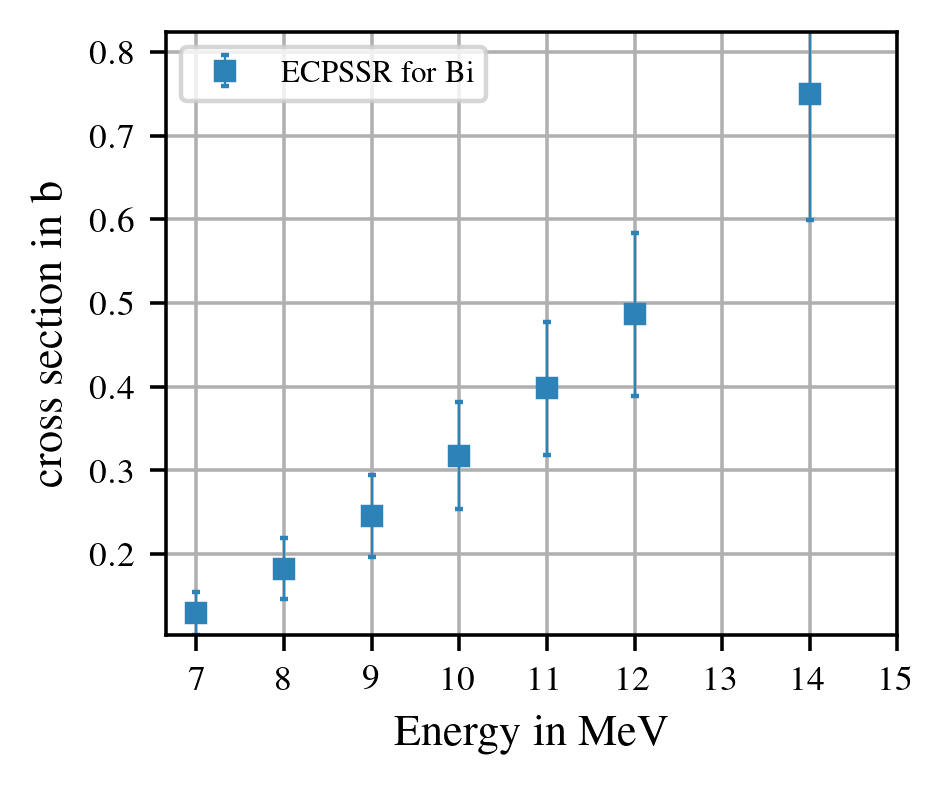

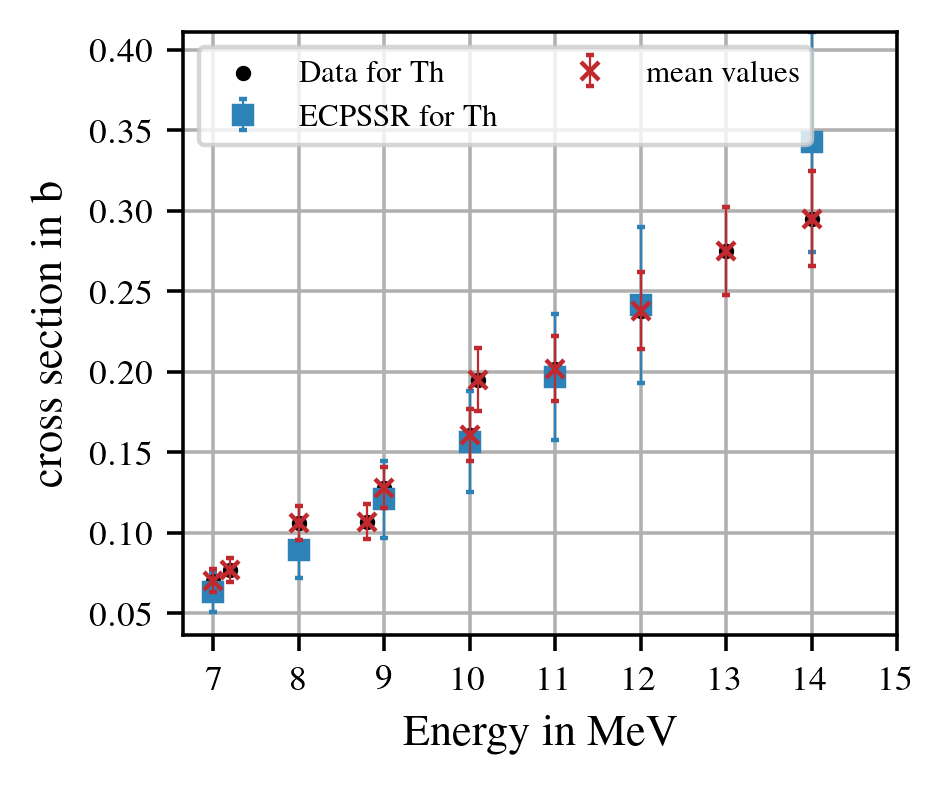

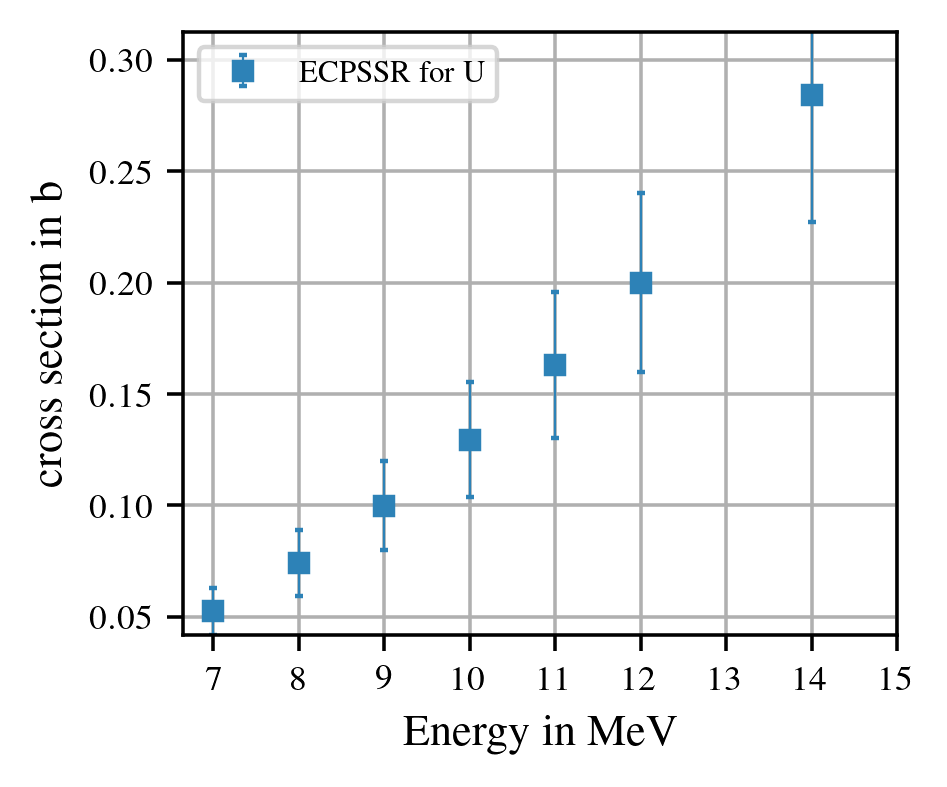

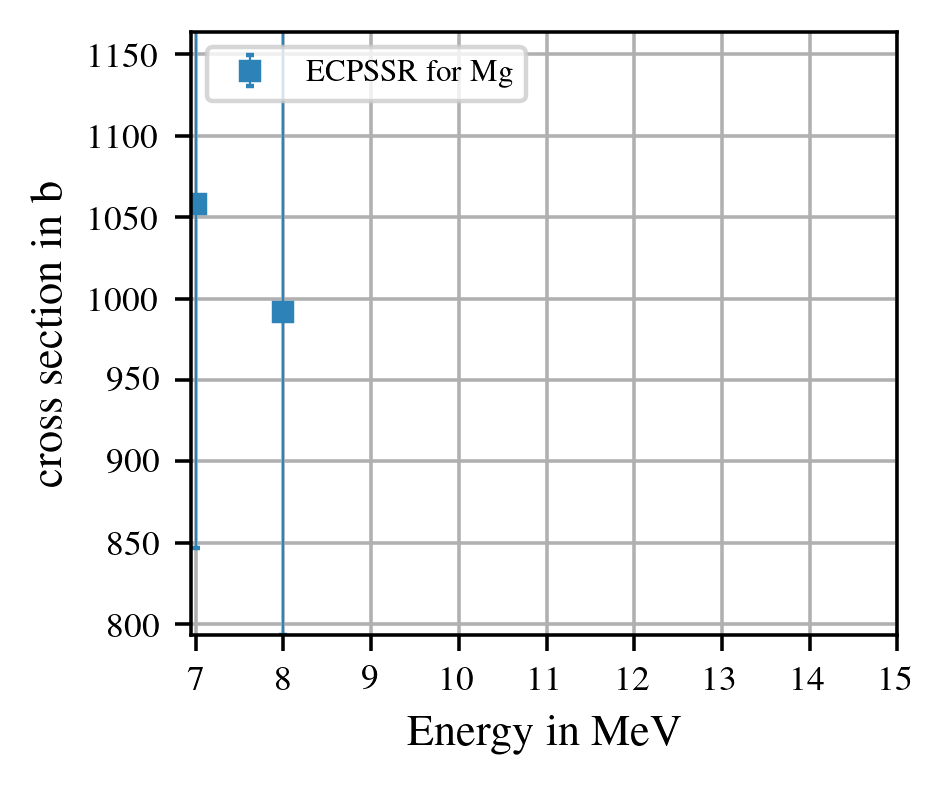

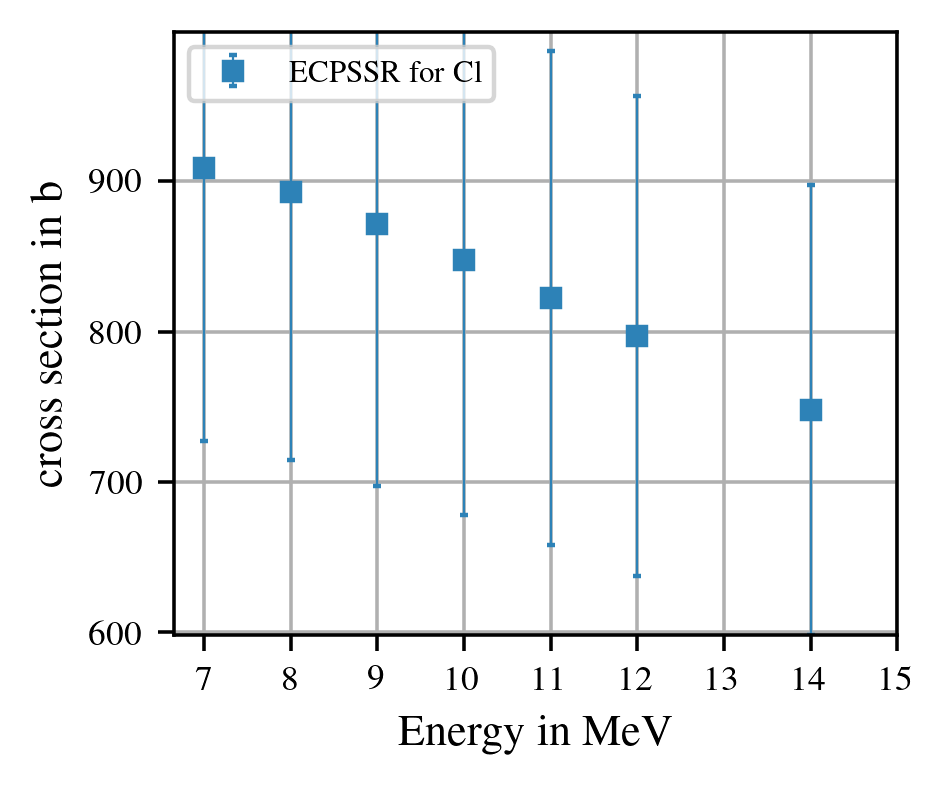

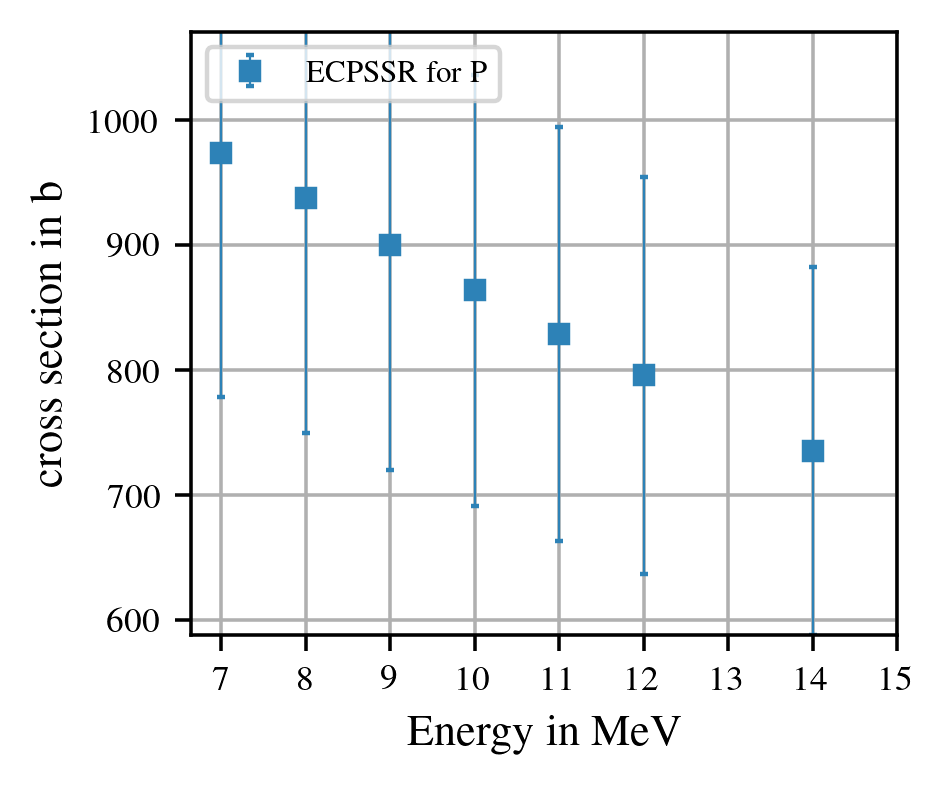

In [18]:
# Ref_plots_lowE(DL=data, captions=captions, colors=colors, M=M, ECPSSR=ECPSSR)
# Ref_plots_highE(DL=data, captions=captions, colors=colors, M=M, ECPSSR=ECPSSR)

In [12]:
print(5.298*10**(32) * 50*10**(-4) * 429 * 10**(-24))

print(0.000218 * 206.786, 0.000218 * 2.049)

1136421000.0
0.045079348000000005 0.000446682


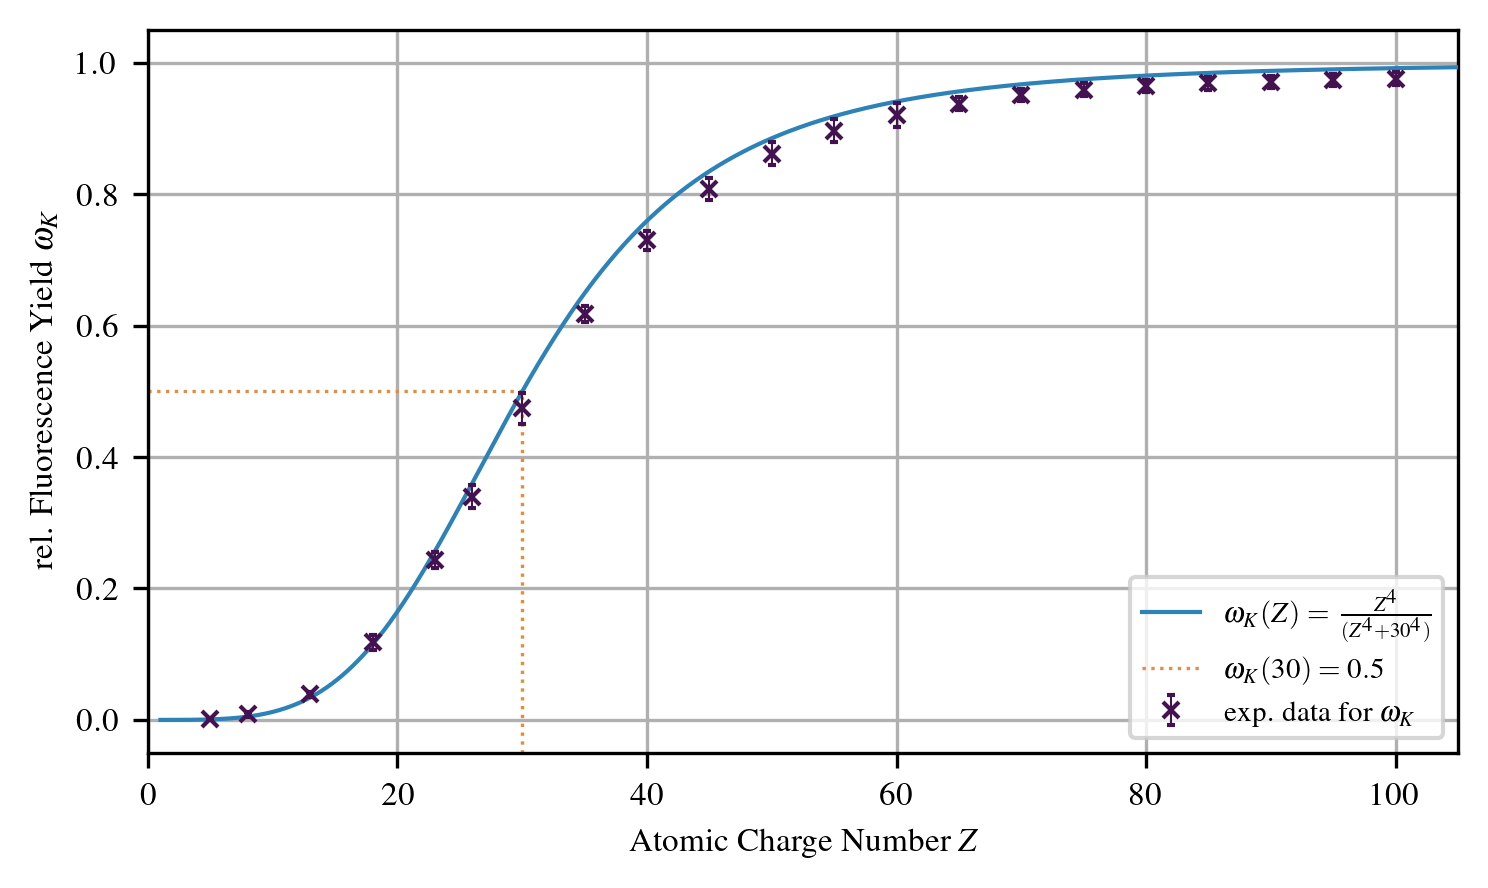

In [55]:
el_val = [5,8,13,18,23,26,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100]
omegaK = [1.7E-3,8.3E-3,0.039,0.118,0.243,0.340,0.474,0.618,0.730,0.808,0.862,0.897,0.921,0.938,0.951,0.959,0.965,0.969,0.971,0.974,0.976]
omegaK_err = [0.4*1.7E-3,0.4*8.3E-3,0.1*0.039,0.1*0.118,0.05*0.243,0.05*0.340,0.05*0.474,0.02*0.618,0.02*0.730,0.02*0.808,0.02*0.862,0.02*0.897,0.02*0.921,0.01*0.938,0.01*0.951,0.01*0.959,0.01*0.965,0.01*0.969,0.01*0.971,0.01*0.974,0.01*0.976]

Z = np.linspace(1,105,1000)
plt.figure(figsize=(5,3), dpi=300)
plt.plot(Z, Z**4/(Z**4 + 30**4), color='#2d82b7', lw=1, label=r'$\omega_K(Z) = \frac{Z^4}{(Z^4 + 30^4)}$', zorder=3)
plt.errorbar(el_val,omegaK,yerr=omegaK_err, c='#441151',fmt='x' , lw=0.5, capsize=1, markersize=4, label=r'exp. data for $\omega_K$', zorder=3)
# plt.scatter(30,0.474, c='#c1292e', s=12,lw=0.6, marker='s', label=r'$\omega_K (Z=30) = 0.474$', zorder=3)
plt.hlines(y=0.5, xmin=-5, xmax=30, ls='dotted', alpha=1, lw=0.8, color='#e08e45', zorder=2, label=r'$\omega_K(30) = 0.5$')
plt.vlines(x=30, ymin=-0.05, ymax=0.5, ls='dotted', alpha=1, lw=0.8, color='#e08e45', zorder=2)
plt.ylim(-0.05,1.05)
plt.xlim(0,105)
plt.xlabel(r'Atomic Charge Number $Z$')
plt.ylabel(r'rel. Fluorescence Yield $\omega_K$')
plt.legend(loc='lower right', ncols=1, fontsize=7)
plt.grid()
plt.tight_layout()
plt.savefig('omegaK.png', dpi=300, transparent=False)
plt.show()